# Краткое описание: Прогноз спроса, роста спроса и оптимизация продаж

**Основная цель:** Оптимизация чистой выручки на предстоящую неделю путем прогноза дополнительного роста продаж (`target_growth`)  за счет глубины скидки и диапазона промо

**Дополнительные возможности:** Прогноз продаж в штуках и в деньгах, прироста в выручке к предыдущей неделе в зависимости от условий промо, создание предпосылки и контекста для планирования стоков (здесь не рассматриваются, но подразумеваемые в качестве леммы)

### Ограничения и предположения:

1. Данные основанные на продажах подразумевают, что отсутствие строк с продажами на уровне SKU в течение недели не является признаком отсутствия предложения (истощения стока). В этой связи отсутствующие на уровне SKU недели заполняются нулевыми продажами и помечаются специальным флагом: количество нулевых недель, чтобы явно указать модели на проблему с данными.
2. Короткая история продаж в распоряжении: ограничена 8 полными неделями. В связи с этим моделирование сезонности остается за рамками задачи, а прогноз сфокусирован на гибкости промо в течение краткосрочного периода.
3. Признаки типа продажи в штуках и деньгах, прирост продаж к предыдущим периодам и пр. рассматриваются на уровне смещения на 1 неделю (`_lw`), что позволяет модели подмечать признаки и характеристики на основании прошлых показателей, а не заглядывать в будущее.

### Полный Глоссарий Признаков

Ниже приведено описание всех признаков, используемых для обучения модели спроса. Признаки сгруппированы по смыслу и источнику данных.

### 1. Целевая Переменная
*   **`target_growth` (TARGET):** Целевая переменная для предсказания. Рассчитывается как `Sales(T) - reg_sales(T)`. **Исключается из обучающей выборки.**
*   **`sku`:** Уникальный идентификатор товара (SKU).
*   **`week`:** Порядковый номер недели продаж (2-10). Используется для временнOго разделения.
*   **`product_id`, `colour_id`**: Составные части SKU.

---

### 2. Ценообразование и Промо (Текущие Входные Данные)
*   **`price_reg`:** Регулярная (полная) цена товара. Неопределенные цены (NaN) заполнены ML моделью.
*   **`has_reg_price`:** Бинарный флаг наличия цены по полной стоимости (1/0). `1`, если у товара была подтвержденная продажа по полной цене в истории.
*   **`price_reg_level`:** Ценовой уровень товара внутри каждой категории (**`product_name`:**) (1 - низкий, 10 - премиальный).
*   **`disc_depth_max`:** Максимальная глубина скидки на текущей неделе (например, 0.30).
*   **`disc_depth_min`:** Минимальная глубина скидки на текущей неделе.
*   **`promo_flag`:** Бинарный флаг наличия промо по строке (1/0). `1`, если `disc_depth_max > 0`.
*   **`base_sale_flag`:** Флаг базового промо обозначенного маркетингом.
*   **`days_before_promo`:** Количество дней с последнего промо (определенного по продажам) для данного SKU.
*   **`has_promo_history`:** Бинарный флаг наличия истории промо (для явного определения NaN).
*   **`days_before_base`:** Количество дней с последнего базового промо.
*   **`has_base_history`:** Бинарный флаг наличия истории базовых промо.

---

### 3. Показатели продаж за предыдущие периоды
*   **`sales_prev_week`:** Выручка (Rub) за предыдущую неделю (`week - 1`).
*   **`quantity_prev_week`:** Количество проданного товара в штуках за предыдущую неделю.
*   **`avg_price_prev_week`:** Средняя цена транзакции за предыдущую неделю.
*   **`n_clients_prev_week`:** Количество уникальных покупателей за предыдущую неделю.
*   **`avg_gender_prev_week`:** Средний пол покупателей (1=М, 0=Ж) за прошлую неделю (усредненный).
*   **`sales_avg_w1w2`:** Средние продажи за последние 2 недели.
*   **`sales_avg_ww1_4`:** Средние продажи за последние 4 недели.
*   **`units_avg_w1w2`:** Средние продажи в штуках за последние 2 недели.
*   **`units_avg_ww1_4`:** Средние продажи в штуках за последние 4 недели.
*  **`weeks_used_for_avg_ww1_4`:** вспомогательный индикатор, указывающий на количество недель, используемых для подсчета метрики `sales_avg_ww1_4` и `units_avg_ww1_4`
*  **`weeks_used_for_avg_w1w2`:** вспомогательный индикатор, указывающий на количество недель, используемых для подсчета метрики `sales_avg_w1w2` и `units_avg_w1w2`
*   **`sales_trend_ww1_2_vs_ww3_4`:** Отношение продаж (Посл. 2 недели / Посл. 2 недели 2 недели назад: LW-2/PW-2). Для определения прироста/спада за двухнедельный период (ускорение тренда).
*   **`weeks_used_for_history`:** Количество предыдущих недель, используемое для подсчета средних агрегированных  значений исторического периода (простое current week - 2)
*   **`inconsistency_w2`:** Уровень изменчивости продаж за последние 2 недели (волатильность).

---

### 4. Реакция на Промо (Историческая)
*   **`promo_units_share_lw`:** Доля штук, проданных со скидкой *на прошлой неделе*. Эквивалент эластичности товара.
*   **`disc_cost_depth_lw`:**  Глубина скидки в деньгах *на прошлой неделе*.
*   **`is_discount_avg_last4w`:** Средняя частота пребывания товара в рамках промо за последние 4 недели.
*   **`disc_depth_avg_last4w`:** Средняя величина скидки за последние 4 недели.

---

### 5. Базовый Спрос
*   **`reg_sales`:** Оценка базовых продаж (Baseline). Рассчитана как скользящее среднее (4 недели) по дням без скидок, с заполнением средним по категории при отсутствии истории.
*   **`weeks_used_for_avg_...`:** Количество не нулевых недель, использованных для расчета скользящих средних для периодов (2 недели, 4 недели).

---

### 6. Атрибуты Товара (Неизменные во времени)
*   **Категории:** `prod_adults`, `prod_kids`, `prod_men`, `prod_women` (Гендерные и возрастные бинарные флаги целевой аудитории).
*   **Бренд/Название:** `product_brand`, `product_name` (Категориальные признаки).
*   **Цвет/Цифровые характеристики цвета:**
    *   **Цветовое Пространство:** `L` (Lightness - Яркость), `a` (Green-Red - тип канала Зеленый-Красный), `b` (Blue-Yellow - тип канала Синий-Желтый), `chroma` (Цифровая характеристика насыщенности), `hue_sin`/`hue_cos` (Циклический оттенок для выражение близости пограничных оттенков - красного и фиолетового).
    *   **Восприятие/цветовые модификаторы:** `is_bright`, `is_dark`, `is_iridescent` (перламутр), `is_light`, `is_multicolored`, `is_neutral`, `is_pastel`, `is_rare`, `is_saturated`, `is_texture`.
    *   **Базовый Цвет:** `basic_colour`.

---

### 7. Кластеризация и характеристики категории товара (**`product_name`**)
*   **`clus_1_prev_w` ... `clus_12_prev_w`:** Доля продаж SKU внутри конкретного кластера (K-Means) на прошлой неделе.
*   **`clust_history_cnt`:** Как часто SKU попадал в кластеры исторически.
*   **Характеристики категории товара:**
    *   `category_dict_share`: Доля SKU в ассортименте категории.
    *   `category_sales_lw`: Общие продажи категории за прошлую неделю.
    *   `category_units_lw`: Общие продажи в штуках за прошлую неделю.
    *   `category_disc_depth_avg`: Средняя скидка по всей категории.
    *   `category_clus_1...12_share_lw`: Вклад каждого кластера в общие продажи категории на прошлой неделе.

In [352]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [353]:
df_clients = (
    pd.read_csv(
        'data/df_clients_filled.csv',
        dtype={'id': str, 'city':str, 'country':str},
        usecols=['id', 'city', 'country']
    )
)

df_purchases = (
    pd.read_csv('data/df_purchases.csv', dtype={'id': str, 'city':str, 'country':str})
)

df_purchases = pd.merge(df_purchases, df_clients, on='id', how='left')
df_purchases = df_purchases[df_purchases['country'] == '32']
df_purchases.shape

(780117, 44)

In [354]:
df_purchases.columns

Index(['id', 'product', 'colour', 'cost', 'product_sex', 'base_sale', 'dt',
       'week', 'day_of_week', 'product_id', 'colour_eng', 'colour_id',
       'single_colour', 'basic_colour', 'L', 'a', 'b', 'chroma', 'hue_cos',
       'hue_sin', 'is_bright', 'is_dark', 'is_iridescent', 'is_light',
       'is_multicolored', 'is_neutral', 'is_pastel', 'is_rare', 'is_saturated',
       'is_texture', 'is_uncertain', 'saturation', 'is_colour_block',
       'prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys',
       'prod_girls', 'product_brand', 'product_name', 'gender', 'city',
       'country'],
      dtype='object')

In [355]:
week_min = df_purchases['dt'].min()
week_max = df_purchases['dt'].max()
print('Проверка с каких дней недели начинаются минимальный день и максимальный день:', end='\n\n')

pd.concat(
    [
        df_purchases.loc[df_purchases['dt'] == week_min, ['dt', 'day_of_week', 'week']].drop_duplicates().T,
        df_purchases.loc[df_purchases['dt'] == week_max, ['dt', 'day_of_week', 'week']].drop_duplicates().T
    ],
    axis=1
).set_axis(['min', 'max'], axis=1)

Проверка с каких дней недели начинаются минимальный день и максимальный день:



,min,max
dt,0,58
day_of_week,6,1
week,1,10


In [356]:
mask = (df_purchases['week'] > 1) & (df_purchases['week'] < 10)
df_purchases = df_purchases[mask]

df_purchases['sku'] = df_purchases['product_id'].astype(str) + '_' + df_purchases['colour_id'].astype(str)

df_purchases.shape

(730365, 45)

In [357]:
mask = (df_purchases['base_sale'] == 0)
df_reg_price = df_purchases.loc[mask, ['sku', 'cost', 'base_sale']]
df_reg_price['border_price'] = (
    df_reg_price
    .groupby('sku')
    .transform('quantile', .75)
)['cost']

mask = df_reg_price['border_price'] <= df_reg_price['cost']
df_reg_price = (
    df_reg_price[mask]
    .groupby(['sku', 'cost', 'border_price'])
    .size()
    .reset_index()
    .sort_values(['sku', 0], ascending=[True, False])
    .drop_duplicates(['sku', 'border_price'])
    .drop(columns=['border_price', 0])
    .set_axis(['sku', 'price_reg'], axis=1)
)

df_reg_price['price_reg'] = df_reg_price['price_reg'].abs()
df_reg_price

,sku,price_reg
0,10000_11,2490
1,10001_13,12299
2,10002_13,6999
4,10003_11,11499
5,10003_13,11499
...,...,...
41460,999_11,5999
41461,999_13,5999
41462,999_23,5999
41463,9_11,4999


In [358]:
mask = (df_purchases['base_sale'] == 1)
df_md_price = df_purchases.loc[mask, ['sku', 'cost']]
df_md_price = (df_md_price
                .groupby(['sku'])
                .max()
                .reset_index()
                .set_axis(['sku', 'price_md'], axis=1)
)
df_md_price['price_md'] = df_md_price['price_md'].abs()
df_md_price

,sku,price_md
0,10001_13,10454
1,10004_135,4549
2,10004_145,4899
3,10004_157,4549
4,10007_13,25199
...,...,...
17831,9997_46,2249
17832,9999_2,8447
17833,999_13,4499
17834,999_23,4949


In [359]:
df_common_price = pd.merge(df_reg_price, df_md_price, on='sku', how='inner')
df_common_price['discount'] = 1 - df_common_price['price_md'] / df_common_price['price_reg']
doubt_reg_price_list = df_common_price.loc[df_common_price['discount'] <= 0, 'sku'].tolist()

mask = df_reg_price['sku'].isin(doubt_reg_price_list)
df_reg_price = df_reg_price[~mask]

In [360]:
df_common_price = pd.merge(df_reg_price, df_md_price, on='sku', how='inner')
df_common_price['discount'] = 1 - df_common_price['price_md'] / df_common_price['price_reg']
df_common_price#.loc[df_common_price['discount'] <= 0]

,sku,price_reg,price_md,discount
0,10001_13,12299,10454,0.150012
1,10004_135,6499,4549,0.300046
2,10004_157,6499,4549,0.300046
3,1000_13,1599,1399,0.125078
4,1000_4,1599,1299,0.187617
...,...,...,...,...
5662,9973_5,6299,5039,0.200032
5663,998_13,4999,4399,0.120024
5664,998_3,4999,4399,0.120024
5665,999_13,5999,4499,0.250042


In [361]:
df_purchases.columns

Index(['id', 'product', 'colour', 'cost', 'product_sex', 'base_sale', 'dt',
       'week', 'day_of_week', 'product_id', 'colour_eng', 'colour_id',
       'single_colour', 'basic_colour', 'L', 'a', 'b', 'chroma', 'hue_cos',
       'hue_sin', 'is_bright', 'is_dark', 'is_iridescent', 'is_light',
       'is_multicolored', 'is_neutral', 'is_pastel', 'is_rare', 'is_saturated',
       'is_texture', 'is_uncertain', 'saturation', 'is_colour_block',
       'prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys',
       'prod_girls', 'product_brand', 'product_name', 'gender', 'city',
       'country', 'sku'],
      dtype='object')

### Создание базового датасета на основании продаж продукта понедельно

In [362]:
constant_cat_list = ['is_bright', 'is_dark', 'is_iridescent', 'is_light', 'is_multicolored',
                     'is_neutral', 'is_pastel', 'is_rare', 'is_saturated', 'is_texture', 'is_uncertain',
                     'prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys', 'prod_girls',
                     'product_id', 'product_brand', 'product_name',
                     'colour_id', 'basic_colour', 'L', 'a', 'b', 'chroma', 'hue_cos', 'hue_sin', 'saturation']

In [363]:
df_sku_week_dense = (
    df_purchases
    .groupby(['sku', 'week'])
    .agg({
        'sku': 'count',                 # 'quantity_week'
        'cost': ['sum', 'mean'],        # 'sales_week', 'avg_price_week'
        'id': 'nunique',                # 'n_clients_week'
        'gender': 'mean',               # 'avg_gender'
    })
    .reset_index()
    .set_axis(
        ['sku', 'week', 'quantity_week', 'sales_week', 'avg_price_week',
         'n_clients_week', 'avg_gender'],
        axis=1
    )
)

df_sku_week_dense = pd.merge(df_sku_week_dense, df_reg_price, on='sku', how='left')
df_sku_week_dense['has_reg_price'] = df_sku_week_dense['price_reg'].notna().astype(int)

df_sku_week_dense

,sku,week,quantity_week,sales_week,avg_price_week,n_clients_week,avg_gender,price_reg,has_reg_price
0,10000_11,3,12,29880,2490.0,11,0.583333,2490.0,1
1,10000_11,4,5,12450,2490.0,5,1.000000,2490.0,1
2,10000_11,5,10,24900,2490.0,9,0.600000,2490.0,1
3,10000_11,6,10,24900,2490.0,9,0.700000,2490.0,1
4,10000_11,7,4,9960,2490.0,4,1.000000,2490.0,1
...,...,...,...,...,...,...,...,...,...
170397,9_4,3,3,14997,4999.0,3,0.000000,4999.0,1
170398,9_4,4,3,14997,4999.0,3,0.666667,4999.0,1
170399,9_4,5,1,4999,4999.0,1,0.000000,4999.0,1
170400,9_4,7,1,4999,4999.0,1,1.000000,4999.0,1


In [364]:
pd.merge(
    df_sku_week_dense,
    df_purchases[['prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys', 'prod_girls',
                  'product_brand', 'product_name', 'basic_colour', 'sku']].drop_duplicates(),
    how='left',
    on='sku'
)

,sku,week,quantity_week,sales_week,avg_price_week,n_clients_week,avg_gender,price_reg,has_reg_price,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name,basic_colour
0,10000_11,3,12,29880,2490.0,11,0.583333,2490.0,1,0,0,0,0,0,0,redmi,фитнес,unknown
1,10000_11,4,5,12450,2490.0,5,1.000000,2490.0,1,0,0,0,0,0,0,redmi,фитнес,unknown
2,10000_11,5,10,24900,2490.0,9,0.600000,2490.0,1,0,0,0,0,0,0,redmi,фитнес,unknown
3,10000_11,6,10,24900,2490.0,9,0.700000,2490.0,1,0,0,0,0,0,0,redmi,фитнес,unknown
4,10000_11,7,4,9960,2490.0,4,1.000000,2490.0,1,0,0,0,0,0,0,redmi,фитнес,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170397,9_4,3,3,14997,4999.0,3,0.000000,4999.0,1,0,0,0,0,0,0,fila,шлем,white
170398,9_4,4,3,14997,4999.0,3,0.666667,4999.0,1,0,0,0,0,0,0,fila,шлем,white
170399,9_4,5,1,4999,4999.0,1,0.000000,4999.0,1,0,0,0,0,0,0,fila,шлем,white
170400,9_4,7,1,4999,4999.0,1,1.000000,4999.0,1,0,0,0,0,0,0,fila,шлем,white


In [365]:
df_price_prediction = pd.merge(
    df_sku_week_dense,
    df_purchases[['prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys', 'prod_girls',
                  'product_brand', 'product_name', 'basic_colour', 'sku']].drop_duplicates(),
    how='left',
    on='sku'
)

df_price_prediction['product_id'] = df_price_prediction['sku'].str.split('_').str[0]

df_price_prediction = pd.merge(df_price_prediction, df_md_price, on='sku', how='left')
df_price_prediction['has_price_md'] = df_price_prediction['price_md'].notna().astype(int)

s_reg_from_pr_id = df_price_prediction.groupby(['product_id'])['price_reg'].transform('mean')
mask = df_price_prediction['price_reg'].isna()
df_price_prediction.loc[mask, 'price_reg'] = s_reg_from_pr_id[mask]

s_reg_from_pr_id = df_price_prediction.groupby(['product_id'])['price_md'].transform('mean')
mask = df_price_prediction['price_md'].isna()
#df_price_prediction.loc[mask, 'price_md'] = s_reg_from_pr_id[mask]

mask = df_price_prediction['price_reg'] < df_price_prediction['price_md']
#df_price_prediction.loc[mask, 'price_md'] = df_price_prediction.loc[mask, 'price_reg']
df_price_prediction.loc[mask, 'price_md'] = np.nan

mask = (df_price_prediction['price_reg'].notna()) & (df_price_prediction['price_md'].notna())
avg_dif = (df_price_prediction.loc[mask, 'price_reg'].sum() / df_price_prediction.loc[mask, 'price_md'].sum())
print(f'Среднее соотношение полной стоимости к сниженной стоимости:\n{avg_dif:.4}')

mask = df_price_prediction['price_md'].isna()
df_price_prediction.loc[mask, 'price_md'] = df_price_prediction.loc[mask, 'price_reg'] / avg_dif

df_price_prediction

Среднее соотношение полной стоимости к сниженной стоимости:
1.279


,sku,week,quantity_week,sales_week,avg_price_week,n_clients_week,avg_gender,price_reg,has_reg_price,prod_adults,...,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name,basic_colour,product_id,price_md,has_price_md
0,10000_11,3,12,29880,2490.0,11,0.583333,2490.0,1,0,...,0,0,0,0,redmi,фитнес,unknown,10000,1946.842354,0
1,10000_11,4,5,12450,2490.0,5,1.000000,2490.0,1,0,...,0,0,0,0,redmi,фитнес,unknown,10000,1946.842354,0
2,10000_11,5,10,24900,2490.0,9,0.600000,2490.0,1,0,...,0,0,0,0,redmi,фитнес,unknown,10000,1946.842354,0
3,10000_11,6,10,24900,2490.0,9,0.700000,2490.0,1,0,...,0,0,0,0,redmi,фитнес,unknown,10000,1946.842354,0
4,10000_11,7,4,9960,2490.0,4,1.000000,2490.0,1,0,...,0,0,0,0,redmi,фитнес,unknown,10000,1946.842354,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170397,9_4,3,3,14997,4999.0,3,0.000000,4999.0,1,0,...,0,0,0,0,fila,шлем,white,9,3908.540132,0
170398,9_4,4,3,14997,4999.0,3,0.666667,4999.0,1,0,...,0,0,0,0,fila,шлем,white,9,3908.540132,0
170399,9_4,5,1,4999,4999.0,1,0.000000,4999.0,1,0,...,0,0,0,0,fila,шлем,white,9,3908.540132,0
170400,9_4,7,1,4999,4999.0,1,1.000000,4999.0,1,0,...,0,0,0,0,fila,шлем,white,9,3908.540132,0


In [366]:
feature_list = ['prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys',
       'prod_girls', 'product_brand', 'product_name', 'basic_colour', 'has_reg_price',
                'price_md', 'has_price_md']

df_category_price = df_price_prediction[feature_list + ['price_reg', 'sku']].groupby(feature_list).agg({'price_reg': 'mean', 'sku': 'unique'}).reset_index()

#df_category_price['product_brand_name'] = df_category_price['product_brand'] + '_' + df_category_price['product_name']
#df_category_price['product_color_name'] = df_category_price['basic_colour'] + '_' + df_category_price['product_name']

mask = df_category_price['price_reg'].notna()
X_unknown = df_category_price[~mask].drop(['price_reg', 'sku'], axis=1)
X = df_category_price[mask].drop(['price_reg', 'sku'], axis=1)
y = df_category_price[mask]['price_reg']

num_features = X.select_dtypes(exclude='object').columns.tolist()

cat_features = X.select_dtypes(include='object').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(sparse_output=True, handle_unknown='ignore'), cat_features),
    ('numerical', StandardScaler(), num_features)
], remainder='passthrough')

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=5000,
        early_stopping=True,  # для предотвращения переобучения
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
        verbose=False
    ))
])

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
mae = mean_absolute_error(y_test, pred)
print('Train-test:')
print(f'MAE: {mae:.0f}')
print(f'MAE, % от среднего: {mae / y_test.mean():.1%}\n')

score = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error')
print('Cross validation score:')
print(f'MAE: {-score.mean():.0f}\n'
      f'STD: {score.std():.1f}\n'
      f'Ratio MAE: {-score.std()/score.mean():.1%}\n')

pipe.fit(X, y)
pred = pipe.predict(X)

mae = mean_absolute_error(y, pred)
print('Full data Train-test:')
print(f'MAE: {mae:.0f}')
print(f'MAE, % от среднего: {mae / y_test.mean():.1%}')

df_category_price.loc[~mask, 'price_reg'] = pipe.predict(X_unknown)
df_category_price = df_category_price.explode('sku').rename(columns={'price_reg': 'price_reg_aprox'})

s_aprox_price = pd.merge(df_sku_week_dense['sku'], df_category_price[['sku', 'price_reg_aprox']], on='sku', how='left')['price_reg_aprox']
mask = df_sku_week_dense['price_reg'].isna()
df_sku_week_dense.loc[mask, 'price_reg'] = s_aprox_price[mask]

Train-test:
MAE: 379
MAE, % от среднего: 5.1%

Cross validation score:
MAE: 581
STD: 90.7
Ratio MAE: 15.6%

Full data Train-test:
MAE: 313
MAE, % от среднего: 4.2%


MLPRegressor был выбран для расчета цен из-за отличной производительности MSE по сравнению с линейными базовыми  показателями (здесь эти исследования не отображены), позволяющей учитывать нелинейные стратегии ценообразования различных брендов и сложность ценовой политики, с которой пришлось столкнуться в данном датасете. Для развертывания производства необходим дополнительный анализ затрат и выгод на основе более простого расчета.

In [367]:
df_sku_week_dense

,sku,week,quantity_week,sales_week,avg_price_week,n_clients_week,avg_gender,price_reg,has_reg_price
0,10000_11,3,12,29880,2490.0,11,0.583333,2490.0,1
1,10000_11,4,5,12450,2490.0,5,1.000000,2490.0,1
2,10000_11,5,10,24900,2490.0,9,0.600000,2490.0,1
3,10000_11,6,10,24900,2490.0,9,0.700000,2490.0,1
4,10000_11,7,4,9960,2490.0,4,1.000000,2490.0,1
...,...,...,...,...,...,...,...,...,...
170397,9_4,3,3,14997,4999.0,3,0.000000,4999.0,1
170398,9_4,4,3,14997,4999.0,3,0.666667,4999.0,1
170399,9_4,5,1,4999,4999.0,1,0.000000,4999.0,1
170400,9_4,7,1,4999,4999.0,1,1.000000,4999.0,1


In [368]:
# ценовой уровень sku внутри категории 'product_name'
df_sku_week_dense = pd.merge(
    df_sku_week_dense,
    df_purchases[['sku', 'product_name']].drop_duplicates(),
    on='sku',
    how='left'
)

df_sku_week_dense['price_reg_level'] = (
    df_sku_week_dense
    .groupby(['product_name'])['price_reg']
    .rank(pct=True, method='dense')
    .multiply(10)
    .astype(int)
)

df_sku_week_dense['zero_weeks'] = 8 - (
    df_sku_week_dense
    .groupby(['sku'])['week']
    .transform('nunique')
)

In [369]:
df_sku_week_dense

,sku,week,quantity_week,sales_week,avg_price_week,n_clients_week,avg_gender,price_reg,has_reg_price,product_name,price_reg_level,zero_weeks
0,10000_11,3,12,29880,2490.0,11,0.583333,2490.0,1,фитнес,5,2
1,10000_11,4,5,12450,2490.0,5,1.000000,2490.0,1,фитнес,5,2
2,10000_11,5,10,24900,2490.0,9,0.600000,2490.0,1,фитнес,5,2
3,10000_11,6,10,24900,2490.0,9,0.700000,2490.0,1,фитнес,5,2
4,10000_11,7,4,9960,2490.0,4,1.000000,2490.0,1,фитнес,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
170397,9_4,3,3,14997,4999.0,3,0.000000,4999.0,1,шлем,3,2
170398,9_4,4,3,14997,4999.0,3,0.666667,4999.0,1,шлем,3,2
170399,9_4,5,1,4999,4999.0,1,0.000000,4999.0,1,шлем,3,2
170400,9_4,7,1,4999,4999.0,1,1.000000,4999.0,1,шлем,3,2


In [370]:
df_reg_price_reference = df_sku_week_dense[['sku', 'price_reg', 'has_reg_price',
                                            'price_reg_level']].drop_duplicates()
df_reg_price_reference

,sku,price_reg,has_reg_price,price_reg_level
0,10000_11,2490.000000,1,5
6,10001_13,12299.000000,1,4
10,10002_13,6999.000000,1,3
13,10003_11,11499.000000,1,8
14,10003_13,11499.000000,1,8
...,...,...,...,...
170381,999_13,5999.000000,1,5
170385,999_23,5999.000000,1,5
170393,99_2,4724.108243,0,4
170395,9_11,4999.000000,1,3


In [371]:
df_sku_prev_week_kpi = df_sku_week_dense[['sku', 'week', 'quantity_week', 'sales_week',
                                          'avg_price_week', 'n_clients_week', 'avg_gender']].copy()
df_sku_prev_week_kpi.columns = ['sku', 'week', 'quantity_prev_week', 'sales_prev_week', 'avg_price_prev_week', 'n_clients_prev_week', 'avg_gender_prev_week']
df_sku_prev_week_kpi['week'] = df_sku_prev_week_kpi['week'].add(1)
df_sku_prev_week_kpi

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week
0,10000_11,4,12,29880,2490.0,11,0.583333
1,10000_11,5,5,12450,2490.0,5,1.000000
2,10000_11,6,10,24900,2490.0,9,0.600000
3,10000_11,7,10,24900,2490.0,9,0.700000
4,10000_11,8,4,9960,2490.0,4,1.000000
...,...,...,...,...,...,...,...
170397,9_4,4,3,14997,4999.0,3,0.000000
170398,9_4,5,3,14997,4999.0,3,0.666667
170399,9_4,6,1,4999,4999.0,1,0.000000
170400,9_4,8,1,4999,4999.0,1,1.000000


### Создание полного датасета с сеткой sku x week на основании сочетания всех возможных вариантов sku и week и наполнение его данными

In [372]:
df_sku_week = (
    pd.merge(
        pd.DataFrame(df_purchases['sku'].unique()).astype('str'),
        pd.DataFrame(np.append(df_purchases['week'].unique(), 10)).sort_values(0).astype('str'),
        how='cross'
    )
    .set_axis(['sku', 'week'], axis=1)
    .astype({'week':int})
    .sort_values(['sku', 'week'])
    .reset_index(drop=True)
)

df_sku_week

,sku,week
0,10000_11,2
1,10000_11,3
2,10000_11,4
3,10000_11,5
4,10000_11,6
...,...,...
405526,9_4,6
405527,9_4,7
405528,9_4,8
405529,9_4,9


In [373]:
# добавление kpi предыдущих недель
df_sku_week = pd.merge(
    df_sku_week,
    df_sku_prev_week_kpi,
    how='left',
    on=['sku', 'week']
)

mask_week2 = df_sku_week['week'].eq(2)
df_sku_week.fillna(0, inplace=True)
mask = df_sku_week.columns.drop(['sku', 'week'])
df_sku_week.loc[mask_week2, mask] = np.nan
df_sku_week['inconsistency_w2'] = mask_week2.astype(np.int8)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0
...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0


In [374]:
# Добавление констант: признаки, характеризующие полную стоимость
df_sku_week = pd.merge(
    df_sku_week,
    df_reg_price_reference,
    how='left',
    on=['sku']
)

# Добавление констант: признаки, характеризующие цвет и продукт
df_sku_week = pd.merge(
    df_sku_week,
    df_purchases[['sku'] + constant_cat_list].drop_duplicates(),
    how='left',
    on=['sku']
)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,product_name,colour_id,basic_colour,L,a,b,chroma,hue_cos,hue_sin,saturation
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,фитнес,11,unknown,50.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,фитнес,11,unknown,50.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,фитнес,11,unknown,50.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,фитнес,11,unknown,50.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,фитнес,11,unknown,50.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,шлем,4,white,100.0,-0.002455,0.004653,0.005261,1.0,0.0,0.0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,шлем,4,white,100.0,-0.002455,0.004653,0.005261,1.0,0.0,0.0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,шлем,4,white,100.0,-0.002455,0.004653,0.005261,1.0,0.0,0.0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,шлем,4,white,100.0,-0.002455,0.004653,0.005261,1.0,0.0,0.0


### Дополнение датасета df_purchases на основании выведенной цены price_reg

In [375]:
df_purchases_expand = df_purchases.copy()
df_purchases_expand = pd.merge(df_purchases_expand, df_category_price[['sku', 'price_reg_aprox']], on='sku', how='left').rename(columns={'price_reg_aprox': 'price_reg'})

df_purchases_expand['disc_depth'] = (1 - df_purchases_expand['cost'] / df_purchases_expand['price_reg']).clip(0, 1)
df_purchases_expand['disc_depth'] = df_purchases_expand['disc_depth']#.round(4)
df_purchases_expand['price_reg'] = df_purchases_expand['price_reg']#.round(2)
df_purchases_expand['is_discount'] = (df_purchases_expand['disc_depth'] > .10).astype(int)
df_purchases_expand['cost_x_disc_depth'] = df_purchases_expand['cost'] * df_purchases_expand['disc_depth']

In [376]:
# пример подсчета средней стоимости вещи на основании продаж
(
    df_purchases_expand['cost']
    .groupby(df_purchases_expand['week'])
    .sum()
    .divide(
        df_purchases_expand['cost']
        .groupby(df_purchases_expand['week'])
        .count()
    )
    .round(2)
)

week
2    5726.31
3    5478.94
4    5301.91
5    5470.11
6    5393.78
7    5245.87
8    5266.84
9    4976.21
Name: cost, dtype: float64

### Добавление промо фичей для регулирования предсказания модели и добавления в тренировочный датасет

Описание признаков, настраиваемых для предсказания:
 1. 'disc_depth_max' - максимальная величина скидки
 2. 'disc_depth_max' - минимальная величина скидки
 3. 'is_disc_depth_mix' - признак того, что цена изменялась динамически в течении недели на данный SKU
 4. 'promo_flag' - флаг наличия промо для конкретного SKU на текущей недели (вычисляемый на основании сравнения цен)
 5. 'base_sale_flag' - флаг наличия промо для конкретного SKU на текущей недели (заявленный отделом продаж/маркетинга)
 6. 'promo_units_share' - доля продаж единиц со скидкой (тех, на которых установлен флаг = 1)
 7. 'disc_cost_depth' - Относительная глубина скидки: средняя скидка от потенциальных продаж в регулярных ценах за неделю.


Для недели предсказания (#10) следующие величины устанавливаются вручную с учетом ожиданий бизнеса. Например, для стока из 10К SKU будет установлена скидка 30% на 2,5К SKU со средней стоимостью в 10 000 рублей и 20% на 3,5К SKU со средней стоимостью в 7 000 рублей при средней стоимости стока AUR в 5000 рублей , тогда параметры 1-5 настраиваются следующим образом:
1. disc_depth_max = 0.3
2. disc_depth_min = 0.2
3. is_disc_depth_mix = 1
4. promo_flag = 1 (всегда)
5. base_sale_flag = 1 (всегда)

В общем случае, модель позволяет манипулировать настройками промо на уровне disc_depth_max, disc_depth_min и is_disc_depth_mix для возможности найти лучшую комбинацию параметров скидки

In [377]:
df_sku_week_pred = (
    df_purchases_expand
    .groupby(['sku', 'week'])
    .agg({
        'cost_x_disc_depth': 'sum',         # 'cost_x_disc_depth'
        'cost': 'sum',                      # 'cost'
        'disc_depth': ['max', 'min'],       # 'disc_depth_max', 'disc_depth_min'
        'is_discount': ['max', 'mean'],     # 'promo_flag', 'promo_units_share'
        'base_sale': 'max'                  # 'base_sale_flag'
    })
    .reset_index()
    .set_axis(
        ['sku', 'week', 'cost_x_disc_depth', 'cost', 'disc_depth_max', 'disc_depth_min',
         'promo_flag', 'promo_units_share', 'base_sale_flag'],
        axis=1
    )
)

df_sku_week_pred.insert(
    df_sku_week_pred.columns.get_loc('disc_depth_min') + 1,
    'is_disc_depth_mix',
    df_sku_week_pred['disc_depth_max'].ne(df_sku_week_pred['disc_depth_min']).astype(int)
)

df_sku_week_pred['disc_cost_depth'] = df_sku_week_pred['cost_x_disc_depth'] / df_sku_week_pred['cost']
df_sku_week_pred = df_sku_week_pred.drop(['cost_x_disc_depth', 'cost'], axis=1)

df_sku_week_pred

,sku,week,disc_depth_max,disc_depth_min,is_disc_depth_mix,promo_flag,promo_units_share,base_sale_flag,disc_cost_depth
0,10000_11,3,0.0,0.0,0,0,0.0,0,0.0
1,10000_11,4,0.0,0.0,0,0,0.0,0,0.0
2,10000_11,5,0.0,0.0,0,0,0.0,0,0.0
3,10000_11,6,0.0,0.0,0,0,0.0,0,0.0
4,10000_11,7,0.0,0.0,0,0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...
170397,9_4,3,0.0,0.0,0,0,0.0,0,0.0
170398,9_4,4,0.0,0.0,0,0,0.0,0,0.0
170399,9_4,5,0.0,0.0,0,0,0.0,0,0.0
170400,9_4,7,0.0,0.0,0,0,0.0,0,0.0


In [378]:
# Ниже приведены kpi для ориентира по настройкам параметров промо promo_units_share и disc_cost_depth
# для данного варианта датасета продаж

print('Cредняя скидка в неделю по сумме в деньгах (disc_cost_depth)'.upper())
print(
    df_purchases_expand['cost']
    .groupby(df_purchases_expand['week'])
    .sum()
    .divide(
        df_purchases_expand['price_reg']
        .groupby(df_purchases_expand['week'])
        .sum()
    )
    .sub(1)
    .round(2)
)
print('\nсредняя скидка в неделю по количеству sku в деньгах (promo_units_share)'.upper())
print(
    df_purchases_expand['is_discount']
    .groupby([df_purchases_expand['sku'], df_purchases_expand['week']])
    .max()
    .reset_index()
    .groupby('week')['is_discount']
    .mean()
    .round(2)
)


CРЕДНЯЯ СКИДКА В НЕДЕЛЮ ПО СУММЕ В ДЕНЬГАХ (DISC_COST_DEPTH)
week
2   -0.04
3   -0.05
4   -0.07
5   -0.07
6   -0.08
7   -0.13
8   -0.14
9   -0.16
dtype: float64

СРЕДНЯЯ СКИДКА В НЕДЕЛЮ ПО КОЛИЧЕСТВУ SKU В ДЕНЬГАХ (PROMO_UNITS_SHARE)
week
2    0.21
3    0.23
4    0.27
5    0.28
6    0.32
7    0.39
8    0.42
9    0.44
Name: is_discount, dtype: float64


In [379]:
# добавление параметров скидки в итоговый датасет
col_list = df_sku_week_pred.columns.drop(['sku', 'week'])


df_sku_week = pd.merge(df_sku_week, df_sku_week_pred, on=['sku', 'week'], how='left')

# проверить вариант с fillna(mean) или ffill() по SKU
df_sku_week[col_list] = df_sku_week[col_list].fillna(0)

In [380]:
# настройка параметров по умолчанию
# 'disc_depth_max', 'disc_depth_min', 'is_disc_depth_mix', 'promo_flag',', 'base_sale_flag', в итоговом датасете

mask = df_sku_week['week'].eq(10)
df_sku_week.loc[mask, 'disc_depth_max'] = .3
df_sku_week.loc[mask, 'disc_depth_min'] = .2
df_sku_week.loc[mask, 'is_disc_depth_mix'] = 1
df_sku_week.loc[mask, ['promo_flag', 'base_sale_flag']] = 1
df_sku_week[mask]

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,hue_cos,hue_sin,saturation,disc_depth_max,disc_depth_min,is_disc_depth_mix,promo_flag,promo_units_share,base_sale_flag,disc_cost_depth
8,10000_11,10,0.0,0.0,0.000000,0.0,0.000000,0,2490.000000,1,...,0.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
17,10001_13,10,2.0,20908.0,10454.000000,2.0,0.500000,0,12299.000000,1,...,1.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
26,10002_13,10,1.0,6999.0,6999.000000,1.0,1.000000,0,6999.000000,1,...,1.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
35,10003_11,10,0.0,0.0,0.000000,0.0,0.000000,0,11499.000000,1,...,0.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
44,10003_13,10,2.0,21398.0,10699.000000,2.0,1.000000,0,11499.000000,1,...,1.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405494,999_13,10,0.0,0.0,0.000000,0.0,0.000000,0,5999.000000,1,...,1.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
405503,999_23,10,11.0,43279.0,3934.454545,10.0,0.909091,0,5999.000000,1,...,1.0,0.000000,1.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
405512,99_2,10,0.0,0.0,0.000000,0.0,0.000000,0,4724.108243,0,...,-0.5,0.866025,1.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0
405521,9_11,10,0.0,0.0,0.000000,0.0,0.000000,0,4999.000000,1,...,0.0,0.000000,0.0,0.3,0.2,1.0,1.0,0.0,1.0,0.0


In [381]:
# замена признаков 'promo_units_share', 'disc_cost_depth' на 'promo_units_share_lw', 'disc_cost_depth_lw'
# для использования в тренировочном датасете
cols = ['promo_units_share', 'disc_cost_depth']

df_sku_week[cols] = df_sku_week.groupby('sku')[cols].shift()
df_sku_week = df_sku_week.rename(columns={c: f'{c}_lw' for c in cols})

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,hue_cos,hue_sin,saturation,disc_depth_max,disc_depth_min,is_disc_depth_mix,promo_flag,promo_units_share_lw,base_sale_flag,disc_cost_depth_lw
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Создание фичей для расчета продаж товаров на основе исторических данных (предыдущих недель) для тренировки модели

## Месячный (4 недели) исторический период для подсчета тренда продаж по полной стоимости - базовые продажи (`reg_sales`)

Понятие базовых продаж вводится для возможности изолирования воздействия промо в реальных продажах, включающих как предложения по полной стоимости, так и распродаже

**Порядок расчета:**
 1. Рассчитываются средние продажи за 4 предыдущие недели товаров (по полной стоимости) которые не принимали участие в промо, из расчета строго исключаются недели с нулевыми продажами по SKU (чтобы отбросить случаи истощения стока и пр. моменты, связанные с проблемами представления товара)
 2. для недели #2, а также для SKU без истории продаж по полной стоимости рассчитываются средние показатели за весь период по категории (`product_name`)
3. **Цель:** Модель учится предсказывать `target_growth` (рост = текущие продажи - базовые продажи `sales_tw` - `reg_sales`), что позволяет создать акцент на дополнительном росте за счет управления настройками промо

In [382]:
mask = df_purchases_expand['is_discount'] == 0
df_purchases_hist = df_purchases_expand.loc[mask, ['sku', 'week', 'cost']].copy()
df_purchases_hist = (
    df_purchases_hist
    .groupby(['sku', 'week'])
    .agg({'cost': 'sum'})
    .reset_index()
)

df_sku_week['reg_sales'] = (
    pd.merge(
        df_sku_week[['sku', 'week']],
        df_purchases_hist,
        on=['sku', 'week'],
        how='left'
    )
    #.fillna(0)                           # без .fillna(0) считает только недели, в которых были продажи
    .groupby(['sku'])
    .rolling(window=4, min_periods=1)['cost'].mean()
    .reset_index(level=0, drop=True)
    .groupby(df_sku_week['sku']).shift()
)

df_sku_week['reg_sales'] = (
    df_sku_week['reg_sales']
    .fillna(
            df_sku_week['reg_sales']
            .groupby(df_sku_week['sku'])
            .transform('mean')
    )
    .fillna(0)                              # проверить точность на mean внутри категории для nan SKU
)



df_sku_week['target_growth'] = (
    df_sku_week['sales_prev_week']
    .groupby(df_sku_week['sku']).shift(-1)
    .sub(df_sku_week['reg_sales'])
)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,saturation,disc_depth_max,disc_depth_min,is_disc_depth_mix,promo_flag,promo_units_share_lw,base_sale_flag,disc_cost_depth_lw,reg_sales,target_growth
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,20364.642857,-20364.642857
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20364.642857,9515.357143
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29880.000000,-17430.000000
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21165.000000,3735.000000
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22410.000000,2490.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9998.000000,-9998.000000
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11664.333333,-6665.333333
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8331.666667,-3332.666667
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4999.000000,-4999.000000


#### Короткий (2 недели и 4 недели) исторический период для продаж всех типов `sku` (полная стоимость и скидка)
 1. Взято 2 и 4 предыдущих недели
 2. для недели #2, рассчитываются средние показатели за весь период
 3. Для недели #3 исторические данные считаются по продажам за неделю #2

In [383]:
df_full_assortiment_hist = (
    pd.merge(
        pd.DataFrame(df_purchases['sku'].unique()).astype('str'),
        pd.DataFrame(np.append(df_purchases['week'].unique(), 10)).sort_values(0).astype('str'),
        how='cross'
    )
    .set_axis(['sku', 'week'], axis=1)
    .astype({'week':int})
)


df_full_assortiment_hist = pd.merge(
    df_full_assortiment_hist,
    (
        df_purchases_expand[['sku', 'week', 'cost', 'is_discount', 'disc_depth']]
        .groupby(['sku', 'week'])
        .agg({'cost': ['sum', 'count'], 'is_discount': 'max', 'disc_depth': 'mean'})
        .set_axis(['sales', 'units', 'is_discount', 'disc_depth'], axis=1)
        .reset_index()
    ),
    how='left',
    on=['sku', 'week']
).sort_values(['sku', 'week']).reset_index(drop=True)

lag = 4

for i in range(1, lag + 1):
    df_full_assortiment_hist[[f'sales_lw_{i}', f'units_lw_{i}']] = (
        df_full_assortiment_hist
        .groupby(['sku'])[['sales', 'units']]
        .shift(i)
    )


df_full_assortiment_hist.fillna(0, inplace=True)


for l in range(1, lag + 1):
    week = l + 1
    mask_ind = df_full_assortiment_hist.index[df_full_assortiment_hist['week'] == week]

    col_mask = df_full_assortiment_hist.columns.str.contains(rf'{l}$', regex=True)
    col_ind = df_full_assortiment_hist.columns.get_indexer(df_full_assortiment_hist.columns[col_mask])[0]

    df_full_assortiment_hist.iloc[mask_ind, col_ind:] = np.nan


for c in ['sales', 'units']:
    df_full_assortiment_hist[f'{c}_avg_w1w2'] = df_full_assortiment_hist[[f'{c}_lw_1', f'{c}_lw_2']].mean(axis=1)

    mask  = df_full_assortiment_hist.columns.str.contains(f'{c}_l')
    cols = df_full_assortiment_hist.columns[mask]
    df_full_assortiment_hist[f'{c}_avg_ww1_4'] = df_full_assortiment_hist[cols].mean(axis=1)

    if c == 'sales':
        df_full_assortiment_hist[f'{c}_trend_ww1_2_vs_ww3_4'] = (
            df_full_assortiment_hist[f'{c}_avg_w1w2']
            -
            df_full_assortiment_hist[[f'{c}_lw_3', f'{c}_lw_4']].mean(axis=1)
        )

# подсчет количества недель используемого для сравнительных периодов (2х недельного,
# 4х недельного, и всего исторического периода)
df_full_assortiment_hist['weeks_used_for_avg_w1w2'] = (df_full_assortiment_hist['week'] - 2).clip(0, 2)
df_full_assortiment_hist['weeks_used_for_avg_ww1_4'] = (df_full_assortiment_hist['week'] - 2).clip(0, 4)
df_full_assortiment_hist['weeks_used_for_history'] = df_full_assortiment_hist['week'] - 2

for c in ['is_discount', 'disc_depth']:
    df_full_assortiment_hist[f'{c}_avg_last4w'] = (
        df_full_assortiment_hist[c]
        .groupby(df_full_assortiment_hist['sku']).shift()
        .groupby(df_full_assortiment_hist['sku']).rolling(window=3, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )

# чуть позже Nan будут заменены глобальными значениями средних внутри sku (или  категории product_name)
df_full_assortiment_hist

,sku,week,sales,units,is_discount,disc_depth,sales_lw_1,units_lw_1,sales_lw_2,units_lw_2,...,sales_avg_w1w2,sales_avg_ww1_4,sales_trend_ww1_2_vs_ww3_4,units_avg_w1w2,units_avg_ww1_4,weeks_used_for_avg_w1w2,weeks_used_for_avg_ww1_4,weeks_used_for_history,is_discount_avg_last4w,disc_depth_avg_last4w
0,10000_11,2,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN
1,10000_11,3,29880.0,12.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.00,NaN,0.0,0.000000,1,1,1,0.0,0.0
2,10000_11,4,12450.0,5.0,0.0,0.0,29880.0,12.0,0.0,0.0,...,14940.0,14940.00,NaN,6.0,6.000000,2,2,2,0.0,0.0
3,10000_11,5,24900.0,10.0,0.0,0.0,12450.0,5.0,29880.0,12.0,...,21165.0,14110.00,21165.0,8.5,5.666667,2,3,3,0.0,0.0
4,10000_11,6,24900.0,10.0,0.0,0.0,24900.0,10.0,12450.0,5.0,...,18675.0,16807.50,3735.0,7.5,6.750000,2,4,4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,0.0,0.0,0.0,0.0,4999.0,1.0,14997.0,3.0,...,9998.0,9998.00,0.0,2.0,2.000000,2,4,4,0.0,0.0
405527,9_4,7,4999.0,1.0,0.0,0.0,0.0,0.0,4999.0,1.0,...,2499.5,8748.25,-12497.5,0.5,1.750000,2,4,5,0.0,0.0
405528,9_4,8,4999.0,1.0,0.0,0.0,4999.0,1.0,0.0,0.0,...,2499.5,6248.75,-7498.5,0.5,1.250000,2,4,6,0.0,0.0
405529,9_4,9,0.0,0.0,0.0,0.0,4999.0,1.0,4999.0,1.0,...,4999.0,3749.25,2499.5,1.0,0.750000,2,4,7,0.0,0.0


In [384]:
# набор фичей для передачи в основной датасет
col_to_pass = ['sku', 'week',
       'sales_avg_w1w2', 'sales_avg_ww1_4',
       'sales_trend_ww1_2_vs_ww3_4', 'units_avg_w1w2', 'units_avg_ww1_4',
       'weeks_used_for_avg_w1w2', 'weeks_used_for_avg_ww1_4',
       'weeks_used_for_history', 'is_discount_avg_last4w', 'disc_depth_avg_last4w']

df_sku_week = pd.merge(
    df_sku_week,
    df_full_assortiment_hist[col_to_pass],
    how='left',
    on=['sku', 'week']
)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,sales_avg_w1w2,sales_avg_ww1_4,sales_trend_ww1_2_vs_ww3_4,units_avg_w1w2,units_avg_ww1_4,weeks_used_for_avg_w1w2,weeks_used_for_avg_ww1_4,weeks_used_for_history,is_discount_avg_last4w,disc_depth_avg_last4w
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.0,0.00,NaN,0.0,0.000000,1,1,1,0.0,0.0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,14940.0,14940.00,NaN,6.0,6.000000,2,2,2,0.0,0.0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,21165.0,14110.00,21165.0,8.5,5.666667,2,3,3,0.0,0.0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,18675.0,16807.50,3735.0,7.5,6.750000,2,4,4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,9998.0,9998.00,0.0,2.0,2.000000,2,4,4,0.0,0.0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,2499.5,8748.25,-12497.5,0.5,1.750000,2,4,5,0.0,0.0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,2499.5,6248.75,-7498.5,0.5,1.250000,2,4,6,0.0,0.0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,4999.0,3749.25,2499.5,1.0,0.750000,2,4,7,0.0,0.0


In [385]:
for promo in ['promo_flag', 'base_sale_flag']:
    df_sku_week[f'days_before_{promo.split('_')[0]}'] = (
        df_sku_week['week']
        .where(df_sku_week[promo] == 1)
        .groupby(df_sku_week['sku']).shift()
        .groupby(df_sku_week['sku']).ffill()
        .sub(df_sku_week['week']).abs()
        .fillna(9)
        .astype(int)
    )

    df_sku_week[f'has_{promo.split('_')[0]}_history'] = (
        df_sku_week[f'days_before_{promo.split('_')[0]}'].ne(9).astype(int)
    )

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,units_avg_ww1_4,weeks_used_for_avg_w1w2,weeks_used_for_avg_ww1_4,weeks_used_for_history,is_discount_avg_last4w,disc_depth_avg_last4w,days_before_promo,has_promo_history,days_before_base,has_base_history
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,NaN,0,0,0,NaN,NaN,9,0,9,0
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.000000,1,1,1,0.0,0.0,9,0,9,0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,6.000000,2,2,2,0.0,0.0,9,0,9,0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,5.666667,2,3,3,0.0,0.0,9,0,9,0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,6.750000,2,4,4,0.0,0.0,9,0,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,2.000000,2,4,4,0.0,0.0,9,0,9,0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,1.750000,2,4,5,0.0,0.0,9,0,9,0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,1.250000,2,4,6,0.0,0.0,9,0,9,0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.750000,2,4,7,0.0,0.0,9,0,9,0


### Создание признака влияния кластеров в недельных продажах sku (высчитывается как доля)

In [386]:
def custer_parser(n_weeks):
    df_cluster_share = (
        pd.merge(
            df_purchases_expand[['id', 'sku', 'week']],
            pd.read_csv(f'data/df_cluster_{n_weeks}_weeks.csv', dtype={'id': str}, usecols=['id', 'cluster']),
            how='left',
            on='id'
        )
    )

    df_cluster_share = pd.crosstab(
        [df_cluster_share['sku'], df_cluster_share['week']],
        df_cluster_share['cluster'],
        normalize='index',
    ).set_axis([f'clus_{c}_prev_w' for c in range(1, 13)], axis=1).sort_index().reset_index()

    df_cluster_share['clust_history_cnt'] = (
        df_cluster_share['week'].ne(0)
        .groupby(df_cluster_share['sku']).cumsum()
        .fillna(0)
    )

    df_cluster_share['week'] = df_cluster_share['week'].add(1)
    col_to_pass = df_cluster_share.columns.drop(['sku', 'week'])

    return df_cluster_share, col_to_pass

In [387]:
df_cluster_share, col_to_pass = custer_parser(n_weeks=6)

In [388]:
df_sku_week = pd.merge(
    df_sku_week,
    df_cluster_share,
    how='left',
    on=['sku', 'week']
)

df_sku_week[col_to_pass] = df_sku_week[col_to_pass].fillna(0)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,clus_4_prev_w,clus_5_prev_w,clus_6_prev_w,clus_7_prev_w,clus_8_prev_w,clus_9_prev_w,clus_10_prev_w,clus_11_prev_w,clus_12_prev_w,clust_history_cnt
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.0
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.0,0.166667,0.0,0.0,0.0,0.0,0.25,0.0,0.416667,1.0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.0,0.400000,0.2,0.0,0.0,0.0,0.20,0.0,0.200000,2.0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.0,0.700000,0.0,0.0,0.0,0.0,0.20,0.0,0.100000,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,0.0,1.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,4.0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.0,0.000000,0.0,1.0,0.0,0.0,0.00,0.0,0.000000,5.0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.0,0.000000,0.0,1.0,0.0,0.0,0.00,0.0,0.000000,6.0


In [389]:
df_sku_week.to_csv('data/df_sku_week.csv', index=False)

### Моделирование Признаков Смещения Спроса (Cannibalization & Substitution)

Расчет индикаторов замещения продукта (канибализации) - ситуации, когда скидка на один товар забирает продажи у другого аналогичного товара и не генерирует новый независимый спрос.

Поскольку данные являются разреженными, метрики, описывающие смещение спроса, строятся через агрегирование признаков внутри категории (а не через кросс-эластичную матрицу):

1.  **`category_dict_share`:**
    *   Вычисляет долю товаров (SKU) внутри одной товарной группы (`product_name`), которые были на промо на прошлой неделе.
    *   *Смысл:* Если этот показатель высок, значит рынок "загружен" скидками. В такой ситуации добавление скидки на ещё один SKU внутри категории (`product_name`) даст меньший прирост, чем если бы это был единственный SKU со скидкой. `category_dict_share` - прямой индикатор насыщения спроса.

2.  **`category_sales_lw` & `category_units_lw`:**
    *   Суммарные продажи всей категории (`product_name`) за прошлую неделю.
    *   *Смысл:* Выводит общий спрос на категорию в качестве пары для сопоставления со спросом отдельного SKU внутри категории (`category_dict_share`). Это позволяет модели понять: рост продаж SKU — это его личная заслуга (успешное промо) или просто общая тенденция категории к росту (Organic Category Growth).

3. **Доля кластеров в продажах внутри категории (`category_clus_X_share_lw`):**
    *   Использование кластеризации при определении канибализации путем вычисления вычисляет доли каждого кластера внутри категории за прошлую неделю.
    *   *Смысл:* Это позволяет модели учитывать **закономерность потребления**. Если в категории резко растет доля кластера А, и падает кластер В, модель скорректирует прогноз, понимая, что спрос смещается в другой сегмент.

Эти признаки позволяют модели регулировать предсказания для товаров в категориях с высокой плотностью промо, косвенно учитывая эффект каннибализации без необходимости явного моделирования парных связей между товарами (путем построения перекрестной матрицы эластичности `sku x sku`).

In [390]:
# доля товаров со скидкой внутри наименования продукта за каждую неделю
df_sku_week['category_dict_share'] = (
    df_sku_week['promo_flag']
    .groupby(df_sku_week['sku']).shift()
    .groupby([df_sku_week['week'], df_sku_week['product_name']])
    .transform('mean')
)

# Продажи по наименованию продукта за неделю
df_sku_week[['category_sales_lw', 'category_units_lw']] = (
    df_sku_week[['sales_prev_week', 'quantity_prev_week']]
    .groupby([df_sku_week['product_name'], df_sku_week['week']])
    .transform('sum')
)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,clus_7_prev_w,clus_8_prev_w,clus_9_prev_w,clus_10_prev_w,clus_11_prev_w,clus_12_prev_w,clust_history_cnt,category_dict_share,category_sales_lw,category_units_lw
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,0.0,0.0,0.0,0.00,0.0,0.000000,0.0,NaN,0.0,0.0
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.0,0.0,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.0,0.0,0.0,0.25,0.0,0.416667,1.0,0.000000,37350.0,15.0
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.0,0.0,0.0,0.20,0.0,0.200000,2.0,0.000000,14940.0,6.0
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.0,0.0,0.0,0.20,0.0,0.100000,3.0,0.000000,34860.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,0.0,0.0,0.0,0.00,0.0,0.000000,4.0,0.021538,968141.0,189.0
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,0.0,0.0,0.0,0.00,0.0,0.000000,0.0,0.024615,892305.0,185.0
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,1.0,0.0,0.0,0.00,0.0,0.000000,5.0,0.021538,784992.0,148.0
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,1.0,0.0,0.0,0.00,0.0,0.000000,6.0,0.021538,962923.0,167.0


In [391]:
# средняя величина скидки в неделю внутри наименования продукта
df_avg_disc_depth = (
    df_purchases_expand['disc_depth']
    .groupby([df_purchases_expand['week'], df_purchases_expand['product_name']])
    .mean()
    .reset_index()
    .rename(columns={'disc_depth': 'category_disc_depth_avg'})
)

df_avg_disc_depth['week'] = df_avg_disc_depth['week'].add(1)

df_sku_week = pd.merge(
    df_sku_week,
    df_avg_disc_depth,
    how='left',
    on=['product_name', 'week']
)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,clus_8_prev_w,clus_9_prev_w,clus_10_prev_w,clus_11_prev_w,clus_12_prev_w,clust_history_cnt,category_dict_share,category_sales_lw,category_units_lw,category_disc_depth_avg
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,0.0,0.0,0.00,0.0,0.000000,0.0,NaN,0.0,0.0,NaN
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.0,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,NaN
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.0,0.0,0.25,0.0,0.416667,1.0,0.000000,37350.0,15.0,0.000000
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.0,0.0,0.20,0.0,0.200000,2.0,0.000000,14940.0,6.0,0.000000
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.0,0.0,0.20,0.0,0.100000,3.0,0.000000,34860.0,14.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,0.0,0.0,0.00,0.0,0.000000,4.0,0.021538,968141.0,189.0,0.012400
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,0.0,0.0,0.00,0.0,0.000000,0.0,0.024615,892305.0,185.0,0.011723
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.0,0.0,0.00,0.0,0.000000,5.0,0.021538,784992.0,148.0,0.019576
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.0,0.0,0.00,0.0,0.000000,6.0,0.021538,962923.0,167.0,0.017980


In [392]:
# доля кластеров в продажах внутри наименования продукта (категории)
def product_cluster_parser(n_weeks):
    df_cluster_share = (
        pd.merge(
            df_purchases_expand[['id', 'sku', 'week', 'product_name']],
            pd.read_csv(f'data/df_cluster_{n_weeks}_weeks.csv', dtype={'id': str}, usecols=['id', 'cluster']),
            how='left',
            on='id'
        )
    )

    df_cluster_share = pd.crosstab(
        [df_cluster_share['product_name'], df_cluster_share['week']],
        df_cluster_share['cluster'],
        normalize='index'
    ).set_axis([f'category_clus_{c}_share_lw' for c in range(1, 13)], axis=1).sort_index().reset_index()

    df_cluster_share['week'] = df_cluster_share['week'].add(1)
    col_to_pass = df_cluster_share.columns.drop(['product_name', 'week'])

    return df_cluster_share, col_to_pass


In [393]:
df_cluster_share_prod, col_to_pass = product_cluster_parser(n_weeks=6)

df_sku_week = pd.merge(
    df_sku_week,
    df_cluster_share_prod,
    how='left',
    on=['product_name', 'week']
)

df_sku_week[col_to_pass] = df_sku_week[col_to_pass].fillna(0)

df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,category_clus_3_share_lw,category_clus_4_share_lw,category_clus_5_share_lw,category_clus_6_share_lw,category_clus_7_share_lw,category_clus_8_share_lw,category_clus_9_share_lw,category_clus_10_share_lw,category_clus_11_share_lw,category_clus_12_share_lw
0,10000_11,2,NaN,NaN,NaN,NaN,NaN,1,2490.0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.000000,0.000000,0.266667,0.000000,0.000000,0.000000,0.000000,0.200000,0.0,0.400000
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.000000,0.000000,0.500000,0.166667,0.000000,0.000000,0.000000,0.166667,0.0,0.166667
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.000000,0.000000,0.571429,0.000000,0.000000,0.000000,0.000000,0.214286,0.0,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,0.084656,0.126984,0.253968,0.005291,0.015873,0.037037,0.000000,0.253968,0.0,0.126984
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,0.059459,0.151351,0.172973,0.016216,0.027027,0.016216,0.000000,0.264865,0.0,0.189189
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.081081,0.121622,0.222973,0.006757,0.020270,0.054054,0.006757,0.195946,0.0,0.155405
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.104938,0.061728,0.222222,0.049383,0.043210,0.061728,0.018519,0.209877,0.0,0.135802


### Моделирование признаков по городам для вычисления коэффициента расхождения таргета конкретного города с общим

Используются следующие признаки:
1. Агрегирование по week, product_name, city
2. city_cat_share_lw - доля города в продажах категории (product_name) на прошлой неделе
3. city_cat_share_roll2 - аналогично, со средним окном в две недели
4. city_discount_intensity_lw - доля покупок со скидкой в городе на последней неделе (mean)
5. city_discount_avg_depth_lw - средняя величина скидки (по сумме) в городе на прошедшей неделе
6. city_cluster_k_share_lw - количественная доля каждого кластера (k = 1...12) в продажах (по сумме) в городе на прошлой неделе
7. city_cat_share_tw - (таргет) доля города в продажах категории (product_name)  на текущей недели

In [394]:
df_city_index = (
    df_purchases_expand
    .groupby(['city', 'product_name', 'week'])
    .agg({
        'cost': 'sum',          # для подсчета city_cat_share_lw, city_cat_share_roll2 и city_discount_avg_depth_lw
        'is_discount': 'mean',  # city_discount_intensity_lw
        'price_reg': 'sum'      # для подсчета city_discount_avg_depth_lw
    })
    .reset_index()
    .rename(columns={'is_discount': 'city_discount_intensity'})
)
df_city_index['city_discount_avg_depth'] = 1 - df_city_index['cost'].divide(df_city_index['price_reg'])
df_city_index['city_categoty'] = df_city_index['city'] + '_' + df_city_index['product_name']
df_city_index['key'] = (
    df_city_index['city']
    .add('_')
    .add(df_city_index['product_name'])
    .add('_')
    .add(df_city_index['week'].astype(str))
)

key_list = df_city_index['key'].tolist()

df_city_index

,city,product_name,week,cost,city_discount_intensity,price_reg,city_discount_avg_depth,city_categoty,key
0,0,анорак,7,3249,0.0,3249.000000,0.000000,0_анорак,0_анорак_7
1,0,балетки,2,3799,0.0,3799.000000,0.000000,0_балетки,0_балетки_2
2,0,бейсболка,7,2239,1.0,3199.000000,0.300094,0_бейсболка,0_бейсболка_7
3,0,бейсболка,8,1999,0.0,1999.000000,0.000000,0_бейсболка,0_бейсболка_8
4,0,бейсболка,9,4198,0.5,4398.000000,0.045475,0_бейсболка,0_бейсболка_9
...,...,...,...,...,...,...,...,...,...
91833,999,свитшот,2,1799,1.0,2313.814815,0.222496,999_свитшот,999_свитшот_2
91834,999,свитшот,6,899,1.0,1799.000000,0.500278,999_свитшот,999_свитшот_6
91835,999,толстовка,6,1749,1.0,2349.000000,0.255428,999_толстовка,999_толстовка_6
91836,999,туника,6,1399,1.0,2499.000000,0.440176,999_туника,999_туника_6


In [395]:
df_city_cat_week = (
    pd.merge(
        pd.DataFrame((df_city_index['city'] + '_' + df_city_index['product_name']).unique()),
        pd.DataFrame(df_purchases['week'].unique()).sort_values(0).astype('str'),
        how='cross'
    )
    .set_axis(['city_categoty', 'week'], axis=1)
    .astype({'week':int})
    .sort_values(['city_categoty', 'week'])
    .reset_index(drop=True)
)

df_city_cat_week[['city', 'product_name']] = df_city_cat_week['city_categoty'].str.split('_', expand=True)

df_city_cat_week = (
    pd.merge(
        df_city_cat_week,
        df_city_index.drop(['city', 'product_name'], axis=1),
        how='left',
        on=['city_categoty', 'week']
    )
    .fillna(0)
)

cost_roll2 = (
    df_city_cat_week[['city_categoty', 'week', 'cost']]
    .groupby(['city_categoty'])['cost']
    .rolling(2, 1)
    .mean()
    .reset_index(level=0, drop=True)
)

s_cat_sales = cost_roll2.groupby([df_city_cat_week['product_name'], df_city_cat_week['week']]).transform('sum')
df_city_cat_week['city_cat_share_roll2'] = cost_roll2.divide(s_cat_sales)



df_city_cat_week


,city_categoty,week,city,product_name,cost,city_discount_intensity,price_reg,city_discount_avg_depth,key,city_cat_share_roll2
0,0_анорак,2,0,анорак,0.0,0.0,0.0,0.0,0,0.0
1,0_анорак,3,0,анорак,0.0,0.0,0.0,0.0,0,0.0
2,0_анорак,4,0,анорак,0.0,0.0,0.0,0.0,0,0.0
3,0_анорак,5,0,анорак,0.0,0.0,0.0,0.0,0,0.0
4,0_анорак,6,0,анорак,0.0,0.0,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
246683,9_юбка-шорты,5,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0
246684,9_юбка-шорты,6,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0
246685,9_юбка-шорты,7,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0
246686,9_юбка-шорты,8,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0


In [396]:
df_cluster_share = (
    pd.merge(
        df_purchases_expand[['id', 'city', 'week', 'cost']],
        pd.read_csv('data/df_cluster.csv', dtype={'id': str}, usecols=['id', 'cluster']),
        how='left',
        on='id'
    )
)

df_cluster_share = pd.crosstab(
    [df_cluster_share['city'], df_cluster_share['week']],
    df_cluster_share['cluster'],
    df_cluster_share['cost'],
    aggfunc='sum',
    normalize='index',
).set_axis([f'city_cluster_{c}_share' for c in range(1, 13)], axis=1).sort_index().reset_index()

In [397]:
df_cluster_share

,city,week,city_cluster_1_share,city_cluster_2_share,city_cluster_3_share,city_cluster_4_share,city_cluster_5_share,city_cluster_6_share,city_cluster_7_share,city_cluster_8_share,city_cluster_9_share,city_cluster_10_share,city_cluster_11_share,city_cluster_12_share
0,0,2,0.0,0.0,0.023181,0.132529,0.123343,0.031207,0.000000,0.002986,0.035478,0.160664,0.462035,0.028576
1,0,3,0.0,0.0,0.000000,0.009979,0.089889,0.000000,0.056746,0.017776,0.032275,0.112469,0.336822,0.344044
2,0,4,0.0,0.0,0.027640,0.017718,0.077223,0.000000,0.000000,0.000000,0.317138,0.127644,0.338585,0.094052
3,0,5,0.0,0.0,0.013695,0.116471,0.139124,0.000000,0.014980,0.008556,0.030824,0.455023,0.128847,0.092481
4,0,6,0.0,0.0,0.032702,0.035507,0.000000,0.000000,0.000000,0.221117,0.000000,0.097208,0.531234,0.082232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3418,998,2,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3419,998,5,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3420,999,2,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3421,999,4,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [398]:
df_city_cat_week = (
    pd.merge(
        df_city_cat_week,
        df_cluster_share,
        how='left',
        on=['week', 'city']
    )
)

s_cat_sales = df_city_cat_week.groupby(['product_name', 'week'])['cost'].transform('sum')
df_city_cat_week['city_cat_share'] = df_city_cat_week['cost'].divide(s_cat_sales)

# продажи в городе по категории отсутствуют в течении данной недели city_cat_share_missing
# количество недель с нулевыми продажами по категории в городе zero_week_cat_sales
df_city_cat_week['city_cat_share_missing'] = df_city_cat_week['city_cat_share'].isna().astype(int)
df_city_cat_week['zero_week_cat_sales'] = (
    df_city_cat_week['city_cat_share_missing']
    .groupby([df_city_cat_week['product_name'], df_city_cat_week['city']])
    .transform('sum')
)

df_city_cat_week

,city_categoty,week,city,product_name,cost,city_discount_intensity,price_reg,city_discount_avg_depth,key,city_cat_share_roll2,...,city_cluster_6_share,city_cluster_7_share,city_cluster_8_share,city_cluster_9_share,city_cluster_10_share,city_cluster_11_share,city_cluster_12_share,city_cat_share,city_cat_share_missing,zero_week_cat_sales
0,0_анорак,2,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.031207,0.000000,0.002986,0.035478,0.160664,0.462035,0.028576,0.0,0,0
1,0_анорак,3,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.056746,0.017776,0.032275,0.112469,0.336822,0.344044,0.0,0,0
2,0_анорак,4,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.317138,0.127644,0.338585,0.094052,0.0,0,0
3,0_анорак,5,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.014980,0.008556,0.030824,0.455023,0.128847,0.092481,0.0,0,0
4,0_анорак,6,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.221117,0.000000,0.097208,0.531234,0.082232,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246683,9_юбка-шорты,5,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.051290,0.005531,0.092973,0.010107,0.073184,0.051432,0.256689,0.0,0,0
246684,9_юбка-шорты,6,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.038865,0.000731,0.110543,0.033131,0.097414,0.131871,0.068855,0.0,0,0
246685,9_юбка-шорты,7,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.008330,0.077321,0.117332,0.015200,0.062849,0.158688,0.238406,0.0,0,0
246686,9_юбка-шорты,8,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.059154,0.020515,0.028293,0.011737,0.190437,0.230654,0.125430,0.0,0,0


In [399]:
# заполнение пропусков нулевых продаж по категории в неделю:
window = 2
while True:
    s_cat_sales = (
        df_city_cat_week
        .groupby([df_city_cat_week['product_name'], df_city_cat_week['city']])['cost']
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
        .groupby([df_city_cat_week['product_name'], df_city_cat_week['week']])
        .transform('sum')
        .reset_index(level=0, drop=True)
        .sort_index()
    )

    mask = df_city_cat_week['city_cat_share'].isna()
    df_city_cat_week.loc[mask, 'city_cat_share'] = df_city_cat_week['cost'].divide(s_cat_sales)[mask]
    mask = df_city_cat_week['city_cat_share'].isna()
    if mask.sum() == 0 or window > 8:
        print(f'Цикл {window-1}')
        print(f'Осталось не заполнено нулевых продаж по категории в неделю: {df_city_cat_week['city_cat_share'].isna().sum()}')
        print(f'Доли продаж по городу будут заполнены нулями')
        df_city_cat_week.loc[mask, 'city_cat_share'] = 0
        break
    window += 1

Цикл 8
Осталось не заполнено нулевых продаж по категории в неделю: 4997
Доли продаж по городу будут заполнены нулями


In [400]:
mask = df_city_cat_week.columns.str.contains('clust')
clus_list = df_city_cat_week.columns[mask]
window = 2

while True:
    df_cluster_roll = (
        df_city_cat_week
        .groupby(['city', 'product_name'])[clus_list]
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
        .sort_index()
    )

    mask = df_city_cat_week['city_cluster_1_share'].isna()
    df_city_cat_week.loc[mask, clus_list] = df_cluster_roll[mask]
    mask = df_city_cat_week['city_cluster_1_share'].isna()
    window += 1
    if mask.sum() == 0 or window > 5:

        print(f'Цикл {window-2}')
        print(f'Осталось незаполненных Nan: {mask.sum()}')
        print(f'Они будут заполнены глобальными данными средних по всем неделям в рамках блока категория-город')

        df_cluster_roll_glob = (
            df_city_cat_week
            .groupby(['city', 'product_name'])[clus_list]
            .transform('mean')
            .reset_index(drop=True)
        )

        mask = df_city_cat_week['city_cluster_1_share'].isna()
        df_city_cat_week.loc[mask, clus_list] = df_cluster_roll_glob[mask]

        mask = df_city_cat_week['city_cluster_1_share'].isna()
        print(f'Итоговый результат заполнения Nan: {mask.sum()}')
        break

Цикл 4
Осталось незаполненных Nan: 1166
Они будут заполнены глобальными данными средних по всем неделям в рамках блока категория-город
Итоговый результат заполнения Nan: 0


In [401]:
df_city_cat_week

,city_categoty,week,city,product_name,cost,city_discount_intensity,price_reg,city_discount_avg_depth,key,city_cat_share_roll2,...,city_cluster_6_share,city_cluster_7_share,city_cluster_8_share,city_cluster_9_share,city_cluster_10_share,city_cluster_11_share,city_cluster_12_share,city_cat_share,city_cat_share_missing,zero_week_cat_sales
0,0_анорак,2,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.031207,0.000000,0.002986,0.035478,0.160664,0.462035,0.028576,0.0,0,0
1,0_анорак,3,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.056746,0.017776,0.032275,0.112469,0.336822,0.344044,0.0,0,0
2,0_анорак,4,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.000000,0.317138,0.127644,0.338585,0.094052,0.0,0,0
3,0_анорак,5,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.014980,0.008556,0.030824,0.455023,0.128847,0.092481,0.0,0,0
4,0_анорак,6,0,анорак,0.0,0.0,0.0,0.0,0,0.0,...,0.000000,0.000000,0.221117,0.000000,0.097208,0.531234,0.082232,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246683,9_юбка-шорты,5,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.051290,0.005531,0.092973,0.010107,0.073184,0.051432,0.256689,0.0,0,0
246684,9_юбка-шорты,6,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.038865,0.000731,0.110543,0.033131,0.097414,0.131871,0.068855,0.0,0,0
246685,9_юбка-шорты,7,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.008330,0.077321,0.117332,0.015200,0.062849,0.158688,0.238406,0.0,0,0
246686,9_юбка-шорты,8,9,юбка-шорты,0.0,0.0,0.0,0.0,0,0.0,...,0.059154,0.020515,0.028293,0.011737,0.190437,0.230654,0.125430,0.0,0,0


In [402]:
# обратное свертывание датасета df_city_cat_week

df_city_cat_week = (
    df_city_cat_week[df_city_cat_week['key']
    .isin(key_list)]
    .drop(columns=['key', 'cost', 'price_reg'])
    .reset_index(drop=True)
)

df_city_cat_week['week_hist'] = (
    df_city_cat_week['week'].ne(0)
    .groupby(df_city_cat_week['city_categoty'])
    .cumsum()
)

df_city_cat_week

,city_categoty,week,city,product_name,city_discount_intensity,city_discount_avg_depth,city_cat_share_roll2,city_cluster_1_share,city_cluster_2_share,city_cluster_3_share,...,city_cluster_7_share,city_cluster_8_share,city_cluster_9_share,city_cluster_10_share,city_cluster_11_share,city_cluster_12_share,city_cat_share,city_cat_share_missing,zero_week_cat_sales,week_hist
0,0_анорак,7,0,анорак,0.000000,0.000000,0.002404,0.000000,0.000000,0.018061,...,0.000000,0.166428,0.052279,0.054712,0.433424,0.000000,0.003935,0,0,1
1,0_балетки,2,0,балетки,0.000000,0.000000,0.004241,0.000000,0.000000,0.023181,...,0.000000,0.002986,0.035478,0.160664,0.462035,0.028576,0.004241,0,0,1
2,0_бейсболка,7,0,бейсболка,1.000000,0.300094,0.000698,0.000000,0.000000,0.018061,...,0.000000,0.166428,0.052279,0.054712,0.433424,0.000000,0.001401,0,0,1
3,0_бейсболка,8,0,бейсболка,0.000000,0.000000,0.001394,0.000000,0.000000,0.008642,...,0.000000,0.081235,0.000000,0.217462,0.348468,0.037378,0.001386,0,0,2
4,0_бейсболка,9,0,бейсболка,0.500000,0.045475,0.002202,0.000000,0.000000,0.011521,...,0.280879,0.057628,0.003415,0.012205,0.189124,0.105015,0.003060,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91833,9_экран,5,9,экран,0.000000,0.000000,0.026457,0.000000,0.000000,0.042709,...,0.005531,0.092973,0.010107,0.073184,0.051432,0.256689,0.052327,0,0,1
91834,9_эспандер,3,9,эспандер,1.000000,0.200401,0.002117,0.005134,0.142252,0.003537,...,0.043511,0.042212,0.053924,0.126646,0.111306,0.253269,0.003591,0,0,1
91835,9_эспандер,4,9,эспандер,0.000000,0.000000,0.008507,0.011520,0.194209,0.040041,...,0.011417,0.027347,0.057749,0.057886,0.136321,0.140268,0.015628,0,0,2
91836,9_эспандеры,4,9,эспандеры,0.000000,0.000000,0.058479,0.011520,0.194209,0.040041,...,0.011417,0.027347,0.057749,0.057886,0.136321,0.140268,0.111111,0,0,1


In [403]:
# изменение наименований фичей с учетом смещения недели
def week_converter(df):
    df['week'] += 1

    df.columns = (
        df.columns[:4].tolist() + [f'{col}_lw' for col in df.columns[4:]]
    )
    df['city_cat_share_target'] = (
        df
        .groupby(['city', 'product_name'])['city_cat_share_lw']
        .shift(-1)
    )

    mask = df['week'].ne(10) & df['city_cat_share_target'].isna()
    df.loc[mask, 'city_cat_share_target'] = 0

    return df

In [404]:
df_city_cat_week = week_converter(df_city_cat_week)

In [405]:
df_city_cat_week.describe()

,week,city_discount_intensity_lw,city_discount_avg_depth_lw,city_cat_share_roll2_lw,city_cluster_1_share_lw,city_cluster_2_share_lw,city_cluster_3_share_lw,city_cluster_4_share_lw,city_cluster_5_share_lw,city_cluster_6_share_lw,...,city_cluster_8_share_lw,city_cluster_9_share_lw,city_cluster_10_share_lw,city_cluster_11_share_lw,city_cluster_12_share_lw,city_cat_share_lw,city_cat_share_missing_lw,zero_week_cat_sales_lw,week_hist_lw,city_cat_share_target
count,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,...,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.000000,91838.0,91838.000000,91838.000000,81617.000000
mean,6.246020,0.260248,0.078742,0.043518,0.005876,0.094924,0.016682,0.030227,0.240025,0.021834,...,0.049937,0.054068,0.084486,0.136382,0.226955,0.054825,0.0,0.071169,2.996657,0.035202
std,2.312502,0.370381,0.159477,0.101801,0.019700,0.086323,0.034698,0.053644,0.151148,0.038452,...,0.063393,0.067267,0.095752,0.101297,0.129851,0.125053,0.0,0.493463,2.084258,0.093460
min,3.000000,0.000000,-3.590348,-0.001257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001257,0.0,0.000000,1.000000,0.000000
25%,4.000000,0.000000,0.000000,0.003019,0.000000,0.036656,0.006463,0.014525,0.175390,0.009854,...,0.025638,0.033465,0.059501,0.109355,0.186835,0.003302,0.0,0.000000,1.000000,0.000000
50%,6.000000,0.000000,0.000000,0.010498,0.002937,0.091683,0.013806,0.025731,0.224955,0.019951,...,0.046870,0.048242,0.077144,0.135384,0.218957,0.012373,0.0,0.000000,2.000000,0.005312
75%,8.000000,0.500000,0.134571,0.033365,0.006553,0.124562,0.019331,0.034188,0.283574,0.027068,...,0.063215,0.061855,0.092989,0.151902,0.250078,0.042714,0.0,0.000000,4.000000,0.023974
max,10.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,7.000000,8.000000,1.000000


#### Вычисление коэффициентов городов в продажах категорий

In [406]:
def city_share_model(model, X_train, X_test, y_train, y_test, X_unknown, num_feat, cat_feat, mode='training'):
    preprocessor = ColumnTransformer([
        ('numeric', StandardScaler(), num_feat),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_feat),
    ], remainder='passthrough')


    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    if mode == 'training':
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        print('Full data Train-test:')
        print(f'MAE: {mae:.3f}')
        print(f'MAE, % от среднего: {mae / y_test.mean():.1%}')
        print(f'y_test_mean: {y_test.mean():.3}')
        return mae
    else:
        pipe.fit(pd.concat([X_train, X_test], ignore_index=True), pd.concat([y_train, y_test], ignore_index=True))
        pred = pipe.predict(X_unknown)
        return pred

In [407]:
w = 6
mask_unknown = df_city_cat_week['city_cat_share_target'].isna()
mask_test = df_city_cat_week['week'].eq(w)
col_to_drop = ['city_categoty', 'city_cat_share_target', 'city_cluster_12_share_lw',
               'week', 'city_cat_share_missing_lw']

X = df_city_cat_week.drop(columns=col_to_drop)

num_feat = X.select_dtypes(include=[np.number]).columns.to_list()
cat_feat = X.select_dtypes(exclude=[np.number]).columns.to_list()
X[cat_feat] = X[cat_feat].astype('category')

X_unknown = X[mask_unknown]
X_test = X[mask_test]
X_train = X[~mask_test & ~mask_unknown]

y_test = df_city_cat_week.loc[mask_test, 'city_cat_share_target']
y_train = df_city_cat_week.loc[~mask_test & ~mask_unknown, 'city_cat_share_target']

for model in [LinearRegression(fit_intercept=True), Ridge(alpha=20)]:
    print(type(model).__name__)
    mae = city_share_model(model, X_train, X_test, y_train, y_test, X_unknown, num_feat, cat_feat)
    print('\n')

print(f'Сравнение с MAE LW vs PW')
mask = df_city_cat_week['week'].eq(w)
pred = df_city_cat_week.loc[mask, 'city_cat_share_lw']
y = df_city_cat_week.loc[mask, 'city_cat_share_target']
mae = mean_absolute_error(y, pred)
test_mean = y.mean()
print('Full data Train-test:')
print(f'MAE: {mae:.3f}')
print(f'MAE, % от среднего: {mae / test_mean:.1%}')
print(f'y_test_mean: {y.mean():.3}')


LinearRegression
Full data Train-test:
MAE: 0.027
MAE, % от среднего: 70.4%
y_test_mean: 0.0377


Ridge
Full data Train-test:
MAE: 0.026
MAE, % от среднего: 69.1%
y_test_mean: 0.0377


Сравнение с MAE LW vs PW
Full data Train-test:
MAE: 0.044
MAE, % от среднего: 115.7%
y_test_mean: 0.0377


In [408]:
pred = city_share_model(Ridge(alpha=20), X_train, X_test, y_train, y_test, X_unknown, num_feat, cat_feat, mode='pred')

In [409]:
# нормализация долей города в продажах продукта в деньгах
df_city_share = df_city_cat_week.loc[mask_unknown, ['product_name', 'city']].reset_index(drop=True)
df_city_share['share_loose'] = pred
df_city_share['share_loose'] = df_city_share['share_loose'].clip(0)

share_sum = (
    df_city_share
    .groupby('product_name')['share_loose']
    .transform('sum')
)

df_city_share['share'] = df_city_share['share_loose'].divide(share_sum)
df_city_share.to_csv('data/df_city_share', index=False)

### Предсказание прироста продаж, исходя из условий промо

#### Заполнение пропусков по неделям глобальными значениями по sku

In [410]:
mask = df_sku_week.isna().any()
mask[['sku', 'week']] = True
col_list = mask.index[mask]
df_glob_fillna = (
    df_sku_week[col_list]
    .groupby('sku')
    .transform('mean')
    .drop(columns=['week'])
)

df_sku_week[col_list.drop(['sku', 'week'])] = df_sku_week[col_list.drop(['sku', 'week'])].fillna(df_glob_fillna)
df_sku_week.loc[df_sku_week['week'] == 10, 'target_growth'] = np.nan
df_sku_week

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,category_clus_3_share_lw,category_clus_4_share_lw,category_clus_5_share_lw,category_clus_6_share_lw,category_clus_7_share_lw,category_clus_8_share_lw,category_clus_9_share_lw,category_clus_10_share_lw,category_clus_11_share_lw,category_clus_12_share_lw
0,10000_11,2,5.25,13072.5,1867.5,4.875,0.485417,1,2490.0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,10000_11,3,0.00,0.0,0.0,0.000,0.000000,0,2490.0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,10000_11,4,12.00,29880.0,2490.0,11.000,0.583333,0,2490.0,1,...,0.000000,0.000000,0.266667,0.000000,0.000000,0.000000,0.000000,0.200000,0.0,0.400000
3,10000_11,5,5.00,12450.0,2490.0,5.000,1.000000,0,2490.0,1,...,0.000000,0.000000,0.500000,0.166667,0.000000,0.000000,0.000000,0.166667,0.0,0.166667
4,10000_11,6,10.00,24900.0,2490.0,9.000,0.600000,0,2490.0,1,...,0.000000,0.000000,0.571429,0.000000,0.000000,0.000000,0.000000,0.214286,0.0,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.00,4999.0,4999.0,1.000,0.000000,0,4999.0,1,...,0.084656,0.126984,0.253968,0.005291,0.015873,0.037037,0.000000,0.253968,0.0,0.126984
405527,9_4,7,0.00,0.0,0.0,0.000,0.000000,0,4999.0,1,...,0.059459,0.151351,0.172973,0.016216,0.027027,0.016216,0.000000,0.264865,0.0,0.189189
405528,9_4,8,1.00,4999.0,4999.0,1.000,1.000000,0,4999.0,1,...,0.081081,0.121622,0.222973,0.006757,0.020270,0.054054,0.006757,0.195946,0.0,0.155405
405529,9_4,9,1.00,4999.0,4999.0,1.000,1.000000,0,4999.0,1,...,0.104938,0.061728,0.222222,0.049383,0.043210,0.061728,0.018519,0.209877,0.0,0.135802


### Общая стратегия предсказаний

* Разделение на временные ряды
* Конкурс двух древовидных моделей **CatBoostRegressor** и **LGBMRegressor**
* **Метрика:** RMSE (Root Mean Squared Error) для `target_growth` и процент совпадения предсказаний позитивных исходов роста (decision signals: процент совпадения случаев, когда `target_growth` > 0), на основании которых обычно принимается решение в пользу привлечения того или иного SKU к участию в промо. Предсказываются не абсолютные продажи, а **Uplift** (прирост над базой), что снижает дисперсию.

* Чтобы избежать переобучения на временных рядах, недели разделяются на:
    *
    **Train:** Недели 2-7.
    *
    **Validation:** Неделя 8 (настройка гиперпараметров).
    *
    **Test:** Неделя 9 (Ориентир, по которому оценивается RMSE и процент совпадения).
    *
    **Prediction:** Неделя 10 (Будущее).



In [411]:
week_test = 9
week_valid = week_test - 1
week_train = list(range(2, week_valid))

cols_to_drop =['sku', 'week', 'product_id', 'colour_id', 'target_growth']
mask_unknown = df_sku_week['target_growth'].isna()
mask_test = df_sku_week['week'].eq(week_test)
mask_valid = df_sku_week['week'].eq(week_valid)
mask_train = df_sku_week['week'].isin(week_train)

X = df_sku_week.drop(columns=cols_to_drop)
y = df_sku_week['target_growth']

num_features = X.select_dtypes(include=[np.number]).columns.to_list()
cat_features = X.select_dtypes(exclude=[np.number]).columns.to_list()
X[cat_features] = X[cat_features].astype('category')
#X[num_features] = StandardScaler().fit_transform(X[num_features])

X_unknown = X[mask_unknown]
X_test, y_test =X[mask_test],  y[mask_test]
X_valid, y_valid = X[mask_valid], y[mask_valid]
X_train, y_train =X[mask_train],  y[mask_train]

print(f'Проверка корректности разделения на train-validation-test')
len(X_train) + len(X_valid) + len(X_test) + len(X_unknown) == len(X)

Проверка корректности разделения на train-validation-test


True

In [412]:
print(f'Проверка наличия пропусков для всех фичей и таргета\n:')
df_sku_week.isna().sum() [df_sku_week.isna().sum() > 0]

Проверка наличия пропусков для всех фичей и таргета
:


target_growth    45059
dtype: int64

In [413]:
# инициализация CatBoostRegressor
cbr = CatBoostRegressor(
    loss_function='RMSE',
    iterations=800,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    random_strength=1,
    subsample=0.8,
    verbose=100
)

cbr.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 41568.7774341	test: 29221.5851976	best: 29221.5851976 (0)	total: 132ms	remaining: 1m 45s
100:	learn: 25030.8081588	test: 27205.9530436	best: 26669.9293471 (33)	total: 6.69s	remaining: 46.3s
200:	learn: 22119.4329149	test: 27505.7763688	best: 26669.9293471 (33)	total: 13s	remaining: 38.8s
300:	learn: 20184.6984640	test: 27666.8982778	best: 26669.9293471 (33)	total: 20s	remaining: 33.1s
400:	learn: 18780.8637859	test: 27695.7599410	best: 26669.9293471 (33)	total: 26.4s	remaining: 26.2s
500:	learn: 17661.0087978	test: 27773.7797606	best: 26669.9293471 (33)	total: 32.6s	remaining: 19.5s
600:	learn: 16868.0148688	test: 27749.2383124	best: 26669.9293471 (33)	total: 38.8s	remaining: 12.9s
700:	learn: 16231.9246149	test: 27708.9736450	best: 26669.9293471 (33)	total: 45.2s	remaining: 6.38s
799:	learn: 15645.9716203	test: 27681.0952868	best: 26669.9293471 (33)	total: 51.5s	remaining: 0us

bestTest = 26669.92935
bestIteration = 33

Shrink model to first 34 iterations.


In [414]:
# функция скоринга (подсчета и сравнения RMSE) и доли совпадения положительных исходов
def rmse_computation(model, y, X_test, y_test, df, w=9):
    pred = model.predict(X_test)
    rmse_base = (y_test**2).mean()**.5
    rmse = mean_squared_error(y_test, pred)**.5

    mask_tw = df['week'].eq(w)
    mask_lw = df['week'].eq(w-1)

    pos_outcomes = ((pred > 0) == ((y_test>0).to_numpy())).mean()
    rmse_lag = ((y[mask_lw].reset_index(drop=True) - y[mask_tw].reset_index(drop=True))**2).mean()**.5


    print(f'базовая RMSE: {rmse_base:.0f}')
    print(f'RMSE модели: {rmse:.0f}')
    print(f'Улучшение по отношению к базовой: {1 - rmse/rmse_base:.1%}')
    print(f'Улучшение по отношению к противоположной неделе: {1 - rmse/rmse_lag:.1%}')
    print(f'Позитивные исходы по SKU: {pos_outcomes:.1%}')

    return pred

In [415]:
rmse_computation(cbr, y, X_test, y_test, df_sku_week)

базовая RMSE: 31249
RMSE модели: 26535
Улучшение по отношению к базовой: 15.1%
Улучшение по отношению к противоположной неделе: 20.3%
Позитивные исходы по SKU: 83.4%


array([-4321.57259954, -4785.63442817, -4551.14269568, ...,
       -3634.31286203, -4548.95546762, -4053.74647753], shape=(45059,))

In [416]:
# ф-ция инициализации, загрузки данных в модель и получения прогноза
def modeling(
        df, week_test=9, mode='scoring',
        cols_to_drop=['sku', 'week', 'product_id', 'colour_id', 'target_growth']
):

    week_valid = week_test - 1
    week_train = list(range(2, week_valid))

    mask_unknown = df['target_growth'].isna()
    mask_test = df['week'].eq(week_test)
    mask_valid = df['week'].eq(week_valid)
    mask_train = df['week'].isin(week_train)

    X_df = df.drop(columns=cols_to_drop)
    y = df["target_growth"]

    num_features = X_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_features = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("scaler", StandardScaler(), num_features),
            ("ohe", OneHotEncoder(sparse_output=True, handle_unknown="ignore"), cat_features),
        ]
    )

    m_train = mask_train.to_numpy()
    m_valid = mask_valid.to_numpy()
    m_test = mask_test.to_numpy()
    m_unknown = mask_unknown.to_numpy()

    params = dict(
        objective="regression",
        learning_rate=0.05,
        num_leaves=63,
        min_data_in_leaf=200,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_lambda=10,
        verbose=-1
    )

    lgbm = LGBMRegressor(n_estimators=800, **params)

    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

    if mode == 'scoring':

        X_train = preprocessor.fit_transform(X_df.loc[m_train])
        y_train = y.loc[m_train]

        X_valid = preprocessor.transform(X_df.loc[m_valid])
        y_valid = y.loc[m_valid]

        X_test = preprocessor.transform(X_df.loc[m_test])
        y_test = y.loc[m_test]

        lgbm.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="rmse"
        )

        pred = rmse_computation(lgbm, y, X_test, y_test, df, w=week_test)

        return pred
    else:
        X_train = preprocessor.fit_transform(X_df.loc[m_train | m_valid])
        y_train = y.loc[m_train | m_valid]

        X_test = preprocessor.transform(X_df.loc[m_test])
        y_test = y.loc[m_test]

        X_unknown = preprocessor.transform(X_df.loc[m_unknown])

        lgbm.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric="rmse"
        )

        return lgbm.predict(X_unknown)

In [417]:
pred = modeling(df_sku_week)

базовая RMSE: 31249
RMSE модели: 25340
Улучшение по отношению к базовой: 18.9%
Улучшение по отношению к противоположной неделе: 23.9%
Позитивные исходы по SKU: 82.6%


In [418]:
modeling(df_sku_week.drop('is_disc_depth_mix', axis=1))

базовая RMSE: 31249
RMSE модели: 25650
Улучшение по отношению к базовой: 17.9%
Улучшение по отношению к противоположной неделе: 23.0%
Позитивные исходы по SKU: 84.7%


array([-6525.15701523, -9171.2622972 , -9141.46744671, ...,
         -68.18840969, -4053.28808666, -2333.51824228], shape=(45059,))

Поскольку LGBMRegressor выигрывает по основным метрикам у CatBoostRegressor, первая модель принимается за основную

Ниже проводится проверка на соотвествие предсказаний логике реальных данных (проверка адекватности модели):
1. Скачки таргета в обоих случаях идентичны, а разность в них не представляет хаоса

Для проверки адекватности созданы категориальные признаки:

2. **`disc_depth_max_cat` (Глубина скидки по уровням внутри категории):**
    *   Разбивка `disc_depth_max` на диапазоны (0-5%, 5-10%, ..., 60%+). Позволяет строить графики эластичности и искать "точки перегиба", где увеличение скидки перестает давать прирост.

3. **`product_discount_density` (Плотность/глубина промо внутри категории):**
    *   Разбивка `category_dict_share` на диапазоны. Используется для проверки гипотезы **каннибализации**: ожидается увидеть, что при высокой плотности промо (например, >40% товаров категории со скидкой) средний прирост продаж будет ниже, чем при низкой плотности.

In [419]:
def df_check_builder(df, pred, mask_test=mask_test):
    df_check = df.loc[mask_test, ['disc_depth_max', 'category_dict_share', 'target_growth', 'sales_prev_week']].rename(columns={'target_growth':'real_growth'}).reset_index(drop=True)
    df_check['predicted_growth'] = pred

# вычисление максимальной глубины скидки по категории
    bins = np.array([0, .05, .10, .20, .30, .40, 1.0])
    df_check['disc_depth_max_cat'] = pd.cut(
        df_check['disc_depth_max'],
        bins=bins,
        labels=[f'{b:.0%}' for b in bins[1:]],
        include_lowest=True
    )

    bins = [0, .05, .10, .15, .20, .25, .30, .35, 1] #[0, .10, .25, .40, .60, .80, 1.0]
    df_check['product_discount_density'] = pd.cut(
        df_check['category_dict_share'],
        bins=bins,
        labels=[f'{b:.0%}' for b in bins[1:]],
        include_lowest=True
    )

    return df_check

In [420]:
df_check = df_check_builder(df_sku_week, pred)
df_check

,disc_depth_max,category_dict_share,real_growth,sales_prev_week,predicted_growth,disc_depth_max_cat,product_discount_density
0,0.000000,0.000000,-15562.5,2490.0,-9017.390194,5%,5%
1,0.150012,0.061688,-3690.0,0.0,-4769.840160,20%,10%
2,0.000000,0.219512,-7349.0,0.0,-8914.718173,5%,25%
3,0.000000,0.359807,-11499.0,0.0,-9769.634491,5%,100%
4,0.069571,0.359807,6866.0,10699.0,-2192.697962,10%,100%
...,...,...,...,...,...,...,...
45054,0.000000,0.326776,-29995.0,8997.0,-24124.581443,5%,35%
45055,0.350058,0.326776,37280.0,35992.0,15568.439044,40%,35%
45056,0.000000,0.293062,0.0,0.0,21.050729,5%,30%
45057,0.000000,0.021538,-4999.0,0.0,-3886.033551,5%,5%


In [422]:
# ф-ция построения графиков зависимости роста от процента глубины скидки
def discount_distr_plot(df, col, xlbl, save=False):
    df_distr = (
        df
        .groupby(col, observed=False)
        .agg({
            'predicted_growth': ['mean', 'count'],
            'real_growth': ['mean'],
        })
        .set_axis(['predicted_growth_mean', 'count', 'real_growth_mean'], axis=1)
    )

    display(df_distr)

    plt.figure(figsize=[4, 3])
    plt.bar(df_distr.index, df_distr['predicted_growth_mean'], color='g', alpha=.85)

    plt.figure(figsize=[4, 3])
    plt.plot(df_distr.index, df_distr['predicted_growth_mean'], color='g')
    plt.plot(df_distr.index, df_distr['real_growth_mean'], color='grey')
    plt.fill_between(
        df_distr.index,
        df_distr['real_growth_mean'],
        df_distr[['predicted_growth_mean', 'real_growth_mean']].min(axis=None),#.min(),
        color='grey',
        alpha=0.2
    )
    plt.title('Ганибализация по категории')
    plt.xlabel(xlbl)
    plt.ylabel('Прирост к базовым продажам (Uplift)')

    if save:
        if xlbl == 'Средняя доля товаров со скидкой':
            plt.fill_between(
                df_distr.index,
                df_distr['predicted_growth_mean'],
                df_distr[['predicted_growth_mean', 'real_growth_mean']].min(axis=None),#.min(),
                where=(df_distr.index >= '15%') & (df_distr.index <= '30%'),
                color='green',
                alpha=0.2
            )
        plt.tight_layout()
        plt.savefig(f'report_images/{col}.png')

    plt.show()


,predicted_growth_mean,count,real_growth_mean
disc_depth_max_cat,,,
5%,-7376.942991,35704,-7203.761876
10%,-2522.100432,370,-715.351384
20%,879.269304,1067,3842.440700
30%,35.808782,1902,883.243224
40%,-1163.247363,2805,-179.829413
100%,638.160855,3211,1121.818402


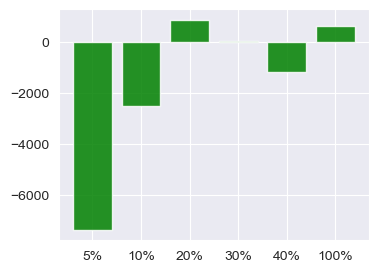

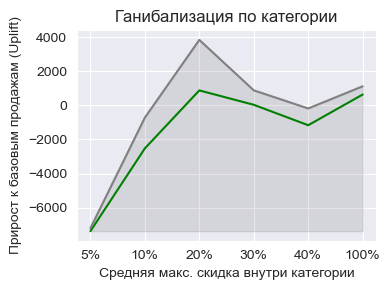

In [423]:
discount_distr_plot(df_check, 'disc_depth_max_cat', 'Средняя макс. скидка внутри категории', save=True)

,predicted_growth_mean,count,real_growth_mean
product_discount_density,,,
5%,-7266.414183,8076,-6824.814994
10%,-6014.394441,5746,-5464.614944
15%,-14820.227178,4732,-13470.392164
20%,-3734.067962,2149,-3845.886338
25%,-6170.552588,3892,-6027.911802
30%,-2102.371661,9886,-2072.818308
35%,-4685.791372,6097,-4678.939744
100%,-4410.138371,4481,-3924.714314


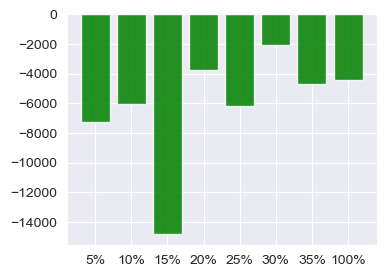

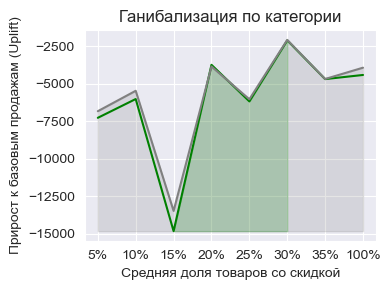

In [424]:
discount_distr_plot(df_check, 'product_discount_density', 'Средняя доля товаров со скидкой', save=True)

In [425]:
def growth_sales_ratio(df, col='predicted_growth'):
    ratio = (
        df[col]
        .divide((df_sku_week.loc[mask_test, 'sales_prev_week'].abs() + 1).reset_index(drop=True))
    )

    ratio.median(),
    print(f'Отношение прироста к выручке за прошлую неделю, 50 персентиль (медиана): {ratio.median():.2f}')
    print(f'Отношение прироста к выручке за прошлую неделю, 95 персентиль : {ratio.quantile(.95):.2f}')
    print(f'Отношение прироста к выручке за прошлую неделю, максимальный : {ratio.max():.2f}\n')

In [426]:
print(f'Для предсказаний ("predicted_growth"):')
growth_sales_ratio(df_check, col='predicted_growth')
print(f'Для реальных данных ("real_growth"):')
growth_sales_ratio(df_check, col='real_growth')

Для предсказаний ("predicted_growth"):
Отношение прироста к выручке за прошлую неделю, 50 персентиль (медиана): -0.98
Отношение прироста к выручке за прошлую неделю, 95 персентиль : 153.93
Отношение прироста к выручке за прошлую неделю, максимальный : 117339.70

Для реальных данных ("real_growth"):
Отношение прироста к выручке за прошлую неделю, 50 персентиль (медиана): -0.78
Отношение прироста к выручке за прошлую неделю, 95 персентиль : 2.00
Отношение прироста к выручке за прошлую неделю, максимальный : 155999.00



В целом, несмотря на то, что распределение на графиках не соответствует гипотезам 2 и 3, можно говорить о здравом смысле работы модели, так как в целом ее предсказания (зеленая линия) повторяют тренд, установленный на реальных данных (серая заливка). При этом модель консервативна в предсказания и сглаживает серьезные скачки, которые могут быть вызваны аномалиями. Сами же отсутсвие логики в реальных данных, скорее, связано с ограниченным их количеством.

#### Проверка предиктивности модели, если провести чистку по аномалиям

* Несмотря на установленный консервативизм в работе модели, ниже предоставляется дополнительная проверка предсказательной работы в случае корректировки данных (чистке аномалий)

##### Проверка таргета

In [427]:
# проверка влияния недели 2
df_2_week_dropped = df_sku_week.copy()
mask = df_2_week_dropped['week'] != 2
df_2_week_dropped = df_2_week_dropped.loc[mask]

modeling(df_2_week_dropped)

базовая RMSE: 31249
RMSE модели: 25274
Улучшение по отношению к базовой: 19.1%
Улучшение по отношению к противоположной неделе: 24.1%
Позитивные исходы по SKU: 87.0%


array([-7926.2123626 , -8869.31620235, -9400.04258137, ...,
         -71.33940963, -4027.84003944, -1817.75264972], shape=(45059,))

In [428]:
df_sku_week_cleaned = df_sku_week.copy()

In [429]:
(
    df_sku_week_cleaned
    .groupby('week')['target_growth']
    .describe(percentiles=[.95, .99, .995, .25, .75, .0025, .01])
    .round(2)
)

,count,mean,std,min,0.2%,1%,25%,50%,75%,95%,99%,99.5%,max
week,,,,,,,,,,,,,
2,45059.0,-975.32,41927.31,-3235991.35,-160502.86,-76998.42,-4599.00,-300.0,766.23,22658.37,88291.93,144629.24,1484262.69
3,45059.0,-2133.92,45185.34,-3235991.35,-210423.29,-92499.42,-5248.79,0.0,849.00,24692.11,94483.84,142745.49,1984984.00
4,45059.0,-8683.99,43485.34,-2423993.35,-301593.68,-126499.00,-8999.00,-2299.0,0.00,9745.65,45962.62,74186.99,489996.50
5,45059.0,-9133.54,47638.10,-2330722.00,-297504.44,-128637.60,-8891.45,-2271.0,0.00,7063.23,33807.94,54990.26,4189989.00
6,45059.0,-8782.72,39924.16,-1840628.75,-280108.21,-125135.38,-8899.00,-2398.0,0.00,6666.82,33319.68,52478.40,2064493.00
7,45059.0,-7763.32,33975.84,-1857627.75,-239296.68,-109303.31,-8199.00,-2205.0,0.00,7148.10,33816.49,55397.45,1397995.67
8,45059.0,-5314.65,29583.61,-893040.00,-183953.81,-89999.00,-6718.50,-1466.0,0.00,10425.20,44547.11,66783.22,1316344.25
9,45059.0,-5516.99,30758.89,-1392627.00,-180275.96,-89683.09,-6597.00,-1449.0,0.00,9248.10,40791.36,63787.12,2024993.25
10,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [430]:
def boxplot_target_growth(df, col='target_growth'):
    boxplot_data = []
    week_labels = []

    for week in range(2, 10):
        mask = df['week'].eq(week)
        week_data = df.loc[mask, col]
        boxplot_data.append(week_data.values)
        week_labels.append(f'Week {week}')

    plt.figure(figsize=(12, 6))
    plt.boxplot(boxplot_data, labels=week_labels)

    plt.title('Распределение роста по неделям')
    plt.ylabel('target_growth')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/hn/ymhf6p891c16lk59vz1f0m9m0000gn/T/ipykernel_83905/56571558.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=week_labels)


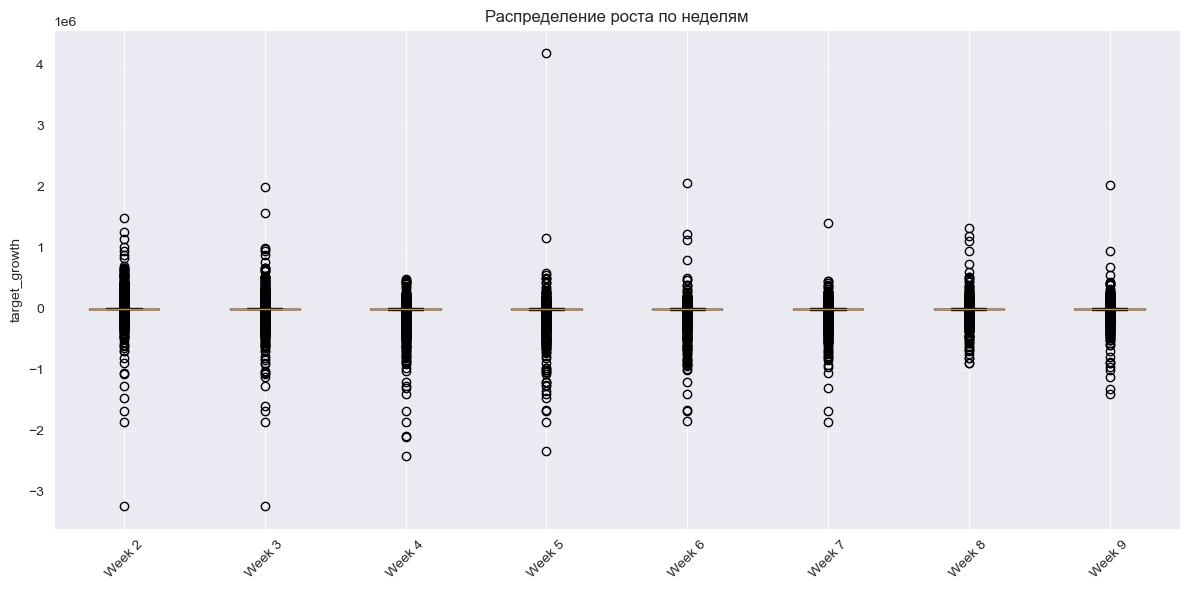

In [431]:
boxplot_target_growth(df_sku_week_cleaned, 'target_growth')

In [432]:
a, b = df_sku_week_cleaned.loc[mask_train, 'target_growth'].quantile([.005, .995])
#df_sku_week_cleaned['target_growth_cleaned'] = df_sku_week_cleaned['target_growth']
df_sku_week_cleaned.loc[mask_train | mask_valid, 'target_growth'] = df_sku_week_cleaned.loc[mask_train | mask_valid, 'target_growth'].clip(a, b)

/var/folders/hn/ymhf6p891c16lk59vz1f0m9m0000gn/T/ipykernel_83905/56571558.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=week_labels)


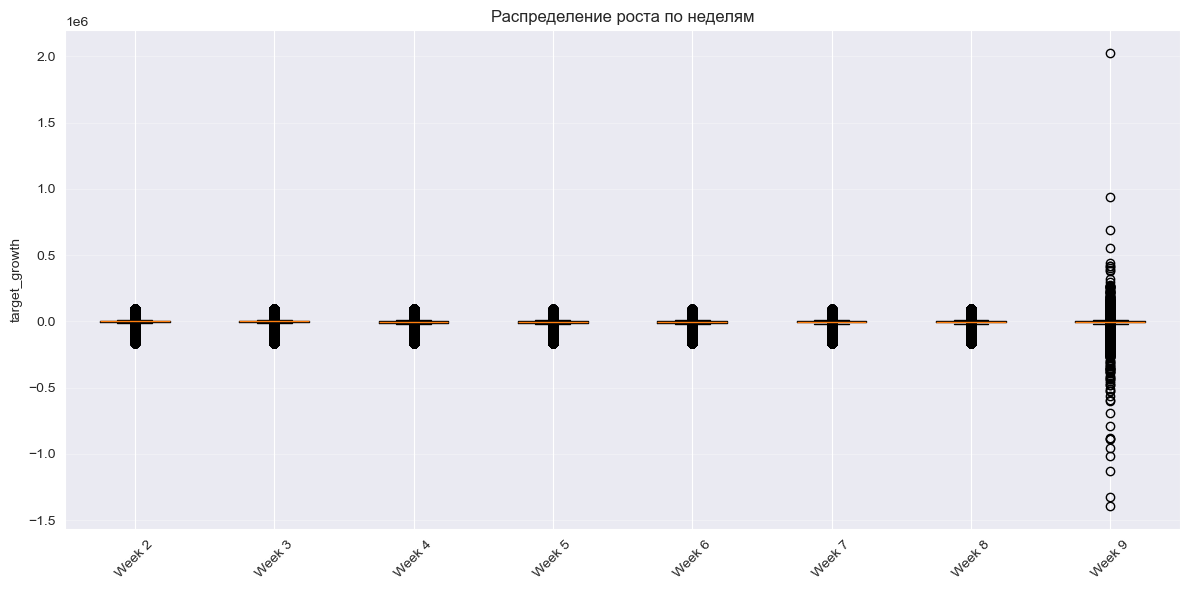

In [433]:
boxplot_target_growth(df_sku_week_cleaned, 'target_growth')

In [434]:
pred_cleaned = modeling(df_sku_week_cleaned)

базовая RMSE: 31249
RMSE модели: 25440
Улучшение по отношению к базовой: 18.6%
Улучшение по отношению к противоположной неделе: 11.2%
Позитивные исходы по SKU: 83.6%


Основные метрики не улучшились, таким образом, для предсказания лучше использовать таргет с без устранения аномалий.

In [435]:
# проверка влияния недели 2
mask = df_sku_week_cleaned['week'] != 2
df_sku_week_cleaned = df_sku_week_cleaned.loc[mask]

pred_cleaned = modeling(df_sku_week_cleaned)

базовая RMSE: 31249
RMSE модели: 25450
Улучшение по отношению к базовой: 18.6%
Улучшение по отношению к противоположной неделе: 11.1%
Позитивные исходы по SKU: 86.6%


Наблюдается ощутимый прирост на совпадение позитивных исходов (принятия решения в пользу промо на основании прибыльности). Можно говорить, что генерализация таргета идет на пользу.

Повторная проверка на логику работы модели с учетом устраненных аномалий

In [436]:
df_check = df_check_builder(df_sku_week_cleaned, pred_cleaned)
df_check

,disc_depth_max,category_dict_share,real_growth,sales_prev_week,predicted_growth,disc_depth_max_cat,product_discount_density
0,0.000000,0.000000,-15562.5,2490.0,-8429.537130,5%,5%
1,0.150012,0.061688,-3690.0,0.0,-8578.215392,20%,10%
2,0.000000,0.219512,-7349.0,0.0,-9147.961874,5%,25%
3,0.000000,0.359807,-11499.0,0.0,-8990.552319,5%,100%
4,0.069571,0.359807,6866.0,10699.0,827.668840,10%,100%
...,...,...,...,...,...,...,...
45054,0.000000,0.326776,-29995.0,8997.0,-27755.714720,5%,35%
45055,0.350058,0.326776,37280.0,35992.0,18535.802474,40%,35%
45056,0.000000,0.293062,0.0,0.0,-60.030182,5%,30%
45057,0.000000,0.021538,-4999.0,0.0,-3960.733204,5%,5%


,predicted_growth_mean,count,real_growth_mean
disc_depth_max_cat,,,
5%,-7092.892861,35704,-7203.761876
10%,-2505.516762,370,-715.351384
20%,202.838511,1067,3842.440700
30%,-293.367161,1902,883.243224
40%,-1518.045439,2805,-179.829413
100%,443.203317,3211,1121.818402


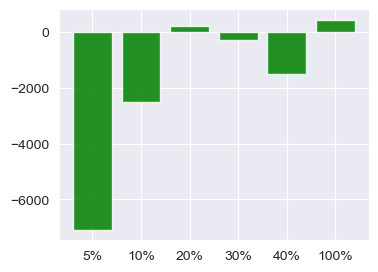

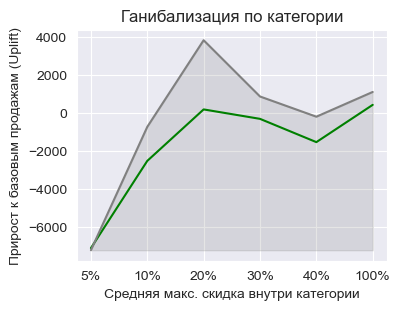

In [437]:
discount_distr_plot(df_check, 'disc_depth_max_cat', 'Средняя макс. скидка внутри категории')

,predicted_growth_mean,count,real_growth_mean
product_discount_density,,,
5%,-7055.762957,8076,-6824.814994
10%,-5886.892130,5746,-5464.614944
15%,-12870.463030,4732,-13470.392164
20%,-3790.348943,2149,-3845.886338
25%,-6635.654090,3892,-6027.911802
30%,-2324.563069,9886,-2072.818308
35%,-4853.764871,6097,-4678.939744
100%,-4260.504298,4481,-3924.714314


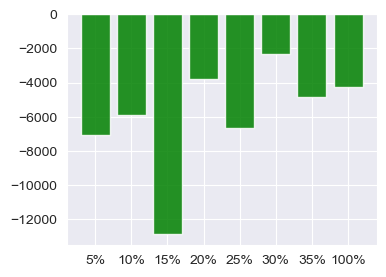

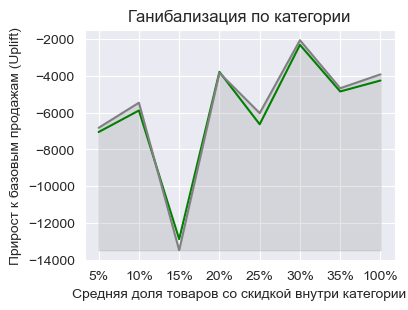

In [438]:
discount_distr_plot(df_check, 'product_discount_density', 'Средняя доля товаров со скидкой внутри категории')

In [439]:
print(f'Для предсказаний ("predicted_growth"):')
growth_sales_ratio(df_check, col='predicted_growth')
print(f'Для реальных данных ("real_growth"):')
growth_sales_ratio(df_check, col='real_growth')

Для предсказаний ("predicted_growth"):
Отношение прироста к выручке за прошлую неделю, 50 персентиль (медиана): -1.99
Отношение прироста к выручке за прошлую неделю, 95 персентиль : 8.45
Отношение прироста к выручке за прошлую неделю, максимальный : 55947.87

Для реальных данных ("real_growth"):
Отношение прироста к выручке за прошлую неделю, 50 персентиль (медиана): -0.78
Отношение прироста к выручке за прошлую неделю, 95 персентиль : 2.00
Отношение прироста к выручке за прошлую неделю, максимальный : 155999.00



##### Исследование основных фичей на аномалии

In [440]:
df_clipped = df_sku_week_cleaned.copy()

In [441]:
features_to_clip = ['quantity_prev_week', 'sales_prev_week',
                    'sales_avg_w1w2', 'sales_avg_ww1_4',
                    'units_avg_w1w2', 'units_avg_ww1_4',
                    'reg_sales', 'n_clients_prev_week',
                    'category_sales_lw', 'category_units_lw']

In [442]:
df_clipped[features_to_clip].describe().round(2)

,quantity_prev_week,sales_prev_week,sales_avg_w1w2,sales_avg_ww1_4,units_avg_w1w2,units_avg_ww1_4,reg_sales,n_clients_prev_week,category_sales_lw,category_units_lw
count,360472.00,360472.00,360472.00,360472.00,360472.00,360472.00,360472.00,360472.00,3.604720e+05,360472.00
mean,2.03,10926.96,11401.44,12297.05,2.10,2.24,16570.64,1.95,1.644963e+07,2827.88
std,6.00,52120.71,51697.75,53098.42,6.04,6.33,57506.12,5.73,2.951143e+07,4038.13
min,0.00,-60.00,-60.00,-60.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,1299.00,0.00,6.421610e+05,189.00
50%,0.00,0.00,1299.50,1799.50,0.50,0.50,5039.00,0.00,3.841659e+06,1090.00
75%,2.00,6799.00,7498.50,8189.00,2.00,2.00,14398.00,2.00,1.649965e+07,3877.00
max,437.00,5001987.00,4517987.50,4517487.75,383.00,383.00,4517487.75,397.00,1.428332e+08,19316.00


In [443]:
for feature in features_to_clip:
    df_clipped[feature] = df_clipped[feature].clip(upper=df_clipped[feature].quantile(.99))

In [444]:
df_clipped[features_to_clip].describe().round(2)

,quantity_prev_week,sales_prev_week,sales_avg_w1w2,sales_avg_ww1_4,units_avg_w1w2,units_avg_ww1_4,reg_sales,n_clients_prev_week,category_sales_lw,category_units_lw
count,360472.00,360472.00,360472.00,360472.00,360472.0,360472.00,360472.00,360472.00,3.604720e+05,360472.00
mean,1.83,8950.07,9384.62,10184.84,1.9,2.03,14326.62,1.76,1.644963e+07,2827.88
std,3.87,22491.47,22433.88,23808.05,3.9,4.11,26893.48,3.70,2.951143e+07,4038.13
min,0.00,-60.00,-60.00,-60.00,0.0,0.00,0.00,0.00,0.000000e+00,0.00
25%,0.00,0.00,0.00,0.00,0.0,0.00,1299.00,0.00,6.421610e+05,189.00
50%,0.00,0.00,1299.50,1799.50,0.5,0.50,5039.00,0.00,3.841659e+06,1090.00
75%,2.00,6799.00,7498.50,8189.00,2.0,2.00,14398.00,2.00,1.649965e+07,3877.00
max,24.00,149778.87,149752.56,159488.29,24.5,26.00,176997.00,23.00,1.428332e+08,19316.00


In [445]:
for level in [.999, .9975, .995, .9925]:
    print(f'{level}')
    df_clipped = df_sku_week_cleaned.copy()
    for feature in features_to_clip:
        df_clipped[feature] = df_clipped[feature].clip(upper=df_clipped[feature].quantile(level))
    modeling(df_clipped)
    print('\n')

0.999
базовая RMSE: 31249
RMSE модели: 25474
Улучшение по отношению к базовой: 18.5%
Улучшение по отношению к противоположной неделе: 11.0%
Позитивные исходы по SKU: 87.1%


0.9975
базовая RMSE: 31249
RMSE модели: 25446
Улучшение по отношению к базовой: 18.6%
Улучшение по отношению к противоположной неделе: 11.1%
Позитивные исходы по SKU: 86.1%


0.995
базовая RMSE: 31249
RMSE модели: 25527
Улучшение по отношению к базовой: 18.3%
Улучшение по отношению к противоположной неделе: 10.9%
Позитивные исходы по SKU: 87.0%


0.9925
базовая RMSE: 31249
RMSE модели: 25550
Улучшение по отношению к базовой: 18.2%
Улучшение по отношению к противоположной неделе: 10.8%
Позитивные исходы по SKU: 87.2%




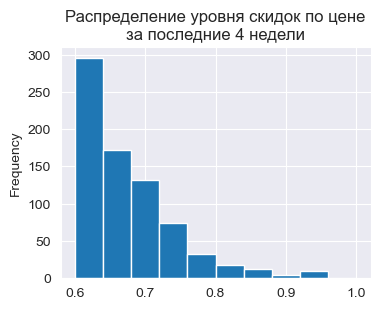

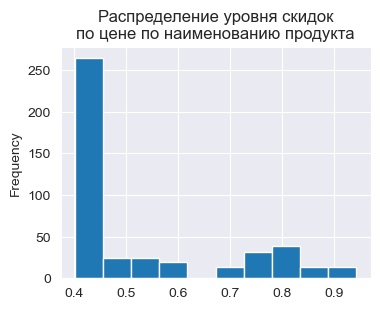

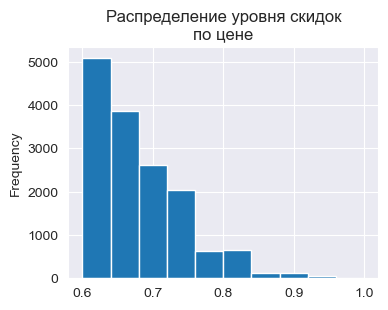

In [446]:
fig = plt.figure(figsize=(4, 3))
df_clipped.loc[df_clipped['disc_depth_avg_last4w'] > .6, 'disc_depth_avg_last4w'].plot(kind='hist');
plt.title('Распределение уровня скидок по цене\nза последние 4 недели')

fig = plt.figure(figsize=(4, 3))
df_clipped.loc[df_clipped['category_disc_depth_avg'] > .4, 'category_disc_depth_avg'].plot(kind='hist');
plt.title('Распределение уровня скидок\nпо цене по наименованию продукта')

fig = plt.figure(figsize=(4, 3))
df_purchases_expand.loc[df_purchases_expand['disc_depth'] > .6, 'disc_depth'].plot(kind='hist');
plt.title('Распределение уровня скидок\nпо цене')

plt.show()

In [447]:
print(f'Наименования товаров с большой средней глубиной скидки (> 80%)'
      f'В целом таких значений немного, что говорит о низком уровне аномалий')
df_clipped.loc[df_clipped['category_disc_depth_avg'] > .8, 'product_name'].value_counts()

Наименования товаров с большой средней глубиной скидки (> 80%)В целом таких значений немного, что говорит о низком уровне аномалий


product_name
оголовник     18
сушилки        8
резинка        8
хвостовики     6
стяжка         5
резинки        3
футляр         2
монтажки       2
Name: count, dtype: int64

In [448]:
print(f'Аналогичный показатель для уровня SKU:')
df_purchases_expand.loc[df_purchases_expand['disc_depth'] > .8, 'product_name'].value_counts()

Аналогичный показатель для уровня SKU:


product_name
сумка         277
купальник     111
велопедали     75
термобелье     59
джемпер        58
             ... 
резинки         1
салфетка        1
система         1
стяжка          1
рюкзак          1
Name: count, Length: 64, dtype: int64

В целом аномалии у всех фичей и можно оставить нетронутыми, продуктивность модели не изменилась, она хорошо справляется с выбросами. Провести корректировку необходимо только скорректировав таргет на выбросы и удалив неделю номер 2 из трейна, потому что большинство значений в ней заполнены средним по всем неделям, это создает шум и уменьшает точность предсказаний, а также лучше убрать из трейна фичу is_disc_depth_mix, она создает проблемы интерпретации на уровне наличия монотонной скидки и, скорее, более шумная, чем показательная

#### Проверка предиктивности модели, если убрать фичи с высокой взаимной корреляцией

In [449]:
df_corr = df_sku_week.copy()
df_corr['target_growth'] = df_corr.pop('target_growth')
cols_categ_corr = df_corr.select_dtypes(exclude=[np.number]).columns.tolist() + ['target_growth', 'week']

for col in ['product_brand', 'product_name','basic_colour']:

    df_corr[col] = (
        df_corr[cols_categ_corr]
        .groupby([col] + ['week'])['target_growth']
        .transform('mean')
    )

df_corr = df_corr[df_corr['week'].ne(10)].drop(columns=['sku', 'week']).corr()

df_corr['target_growth'].abs().sort_values(ascending=False)[1:10]

reg_sales                     0.494031
product_brand                 0.359530
price_reg                     0.317000
product_name                  0.294891
sales_avg_ww1_4               0.288977
sales_avg_w1w2                0.247246
sales_prev_week               0.207928
category_clus_3_share_lw      0.180870
sales_trend_ww1_2_vs_ww3_4    0.175085
Name: target_growth, dtype: float64

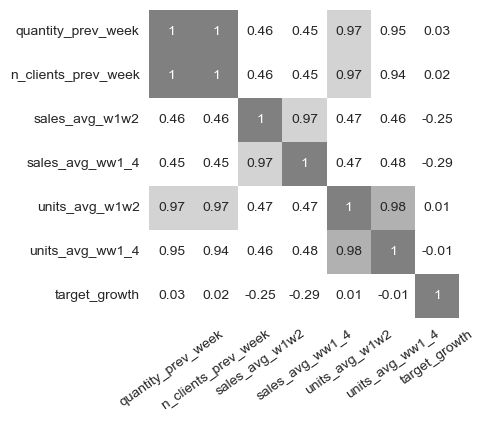

In [450]:
from matplotlib.colors import LinearSegmentedColormap

mask = ((df_corr > .97) & (df_corr != 1)).any()
mask['target_growth'] = True

colors = ['white', 'white', '.5', '.5']
nodes = [0.0, 0.97, .99999, 1.0]

plt.figure(figsize=(4, 4))
cmap = LinearSegmentedColormap.from_list("custom_threshold", list(zip(nodes, colors)))
sns.heatmap(df_corr.loc[mask, mask].round(2), annot=True, cmap=cmap, cbar=False)
plt.xticks(rotation=35)
plt.show()

In [451]:
from itertools import combinations

col_grouped_4 = ['quantity_prev_week', 'n_clients_prev_week', 'units_avg_w1w2', 'units_avg_ww1_4']
feat_to_drop_test = list(combinations(col_grouped_4, 3)) + [['sales_avg_w1w2']] + [['sales_avg_ww1_4']]

for col in feat_to_drop_test:
    print(f'Точность без признаков {col}:')
    modeling(df_sku_week.drop(columns=list(col)))
    print('\n')

Точность без признаков ('quantity_prev_week', 'n_clients_prev_week', 'units_avg_w1w2'):
базовая RMSE: 31249
RMSE модели: 25564
Улучшение по отношению к базовой: 18.2%
Улучшение по отношению к противоположной неделе: 23.2%
Позитивные исходы по SKU: 83.5%


Точность без признаков ('quantity_prev_week', 'n_clients_prev_week', 'units_avg_ww1_4'):
базовая RMSE: 31249
RMSE модели: 25625
Улучшение по отношению к базовой: 18.0%
Улучшение по отношению к противоположной неделе: 23.0%
Позитивные исходы по SKU: 85.9%


Точность без признаков ('quantity_prev_week', 'units_avg_w1w2', 'units_avg_ww1_4'):
базовая RMSE: 31249
RMSE модели: 25933
Улучшение по отношению к базовой: 17.0%
Улучшение по отношению к противоположной неделе: 22.1%
Позитивные исходы по SKU: 84.6%


Точность без признаков ('n_clients_prev_week', 'units_avg_w1w2', 'units_avg_ww1_4'):
базовая RMSE: 31249
RMSE модели: 25732
Улучшение по отношению к базовой: 17.7%
Улучшение по отношению к противоположной неделе: 22.7%
Позитивные исход

В целом, после удаления фичей RMSE упала, как и процент совпадения позитивных исходов. Удаление исследуемых фичей могло бы только улучшить стабильность модели. Итого для окончательного релиза можно оставить признаки с высокой корреляцией как они есть.

### Предсказание абсолютного прироста по сети и его представление

In [452]:
# на основании ранее установленных показателях ожидания от промо

# mask = df_sku_week['week'].eq(10)
# df_sku_week.loc[mask, 'disc_depth_max'] = .3
# df_sku_week.loc[mask, 'disc_depth_min'] = .2
# df_sku_week.loc[mask, 'is_disc_depth_mix'] = 1 (устаревшая метрика)
# df_sku_week.loc[mask, ['promo_flag', 'base_sale_flag']] = 1
# df_sku_week[mask]
#df_sku_week.loc[df_sku_week['week'].eq(10), 'target_growth'] = np.nan

In [470]:
df_sku_week_cleaned = df_sku_week.drop('is_disc_depth_mix', axis=1).copy()

In [471]:
for parser in [custer_parser(n_weeks=7), product_cluster_parser(n_weeks=7)]:
    df_cluster_share, col_to_pass = parser
    df_sku_week_cleaned = df_sku_week_cleaned.drop(columns=col_to_pass)
    df_sku_week_cleaned = pd.merge(
        df_sku_week_cleaned,
        df_cluster_share,
        how='left',
        on=df_cluster_share.columns[0:2].tolist()
    )

    df_sku_week_cleaned[col_to_pass] = df_sku_week_cleaned[col_to_pass].fillna(0)

In [474]:
a, b = df_sku_week_cleaned.loc[mask_train | mask_valid, 'target_growth'].quantile([.005, .995])

df_sku_week_cleaned.loc[~mask_unknown, 'target_growth'] = (
    df_sku_week_cleaned.loc[~mask_unknown, 'target_growth'].clip(a, b)
)

In [475]:
mask = df_sku_week_cleaned['week'] != 2
df_sku_week_cleaned = df_sku_week_cleaned.loc[mask]

df_sku_week_cleaned.to_csv('data/df_sku_week_cleaned.csv', index=False)
df_sku_week_cleaned

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,category_clus_3_share_lw,category_clus_4_share_lw,category_clus_5_share_lw,category_clus_6_share_lw,category_clus_7_share_lw,category_clus_8_share_lw,category_clus_9_share_lw,category_clus_10_share_lw,category_clus_11_share_lw,category_clus_12_share_lw
1,10000_11,3,0.0,0.0,0.0,0.0,0.000000,0,2490.0,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,10000_11,4,12.0,29880.0,2490.0,11.0,0.583333,0,2490.0,1,...,0.000000,0.000000,0.000000,0.200000,0.333333,0.000000,0.000000,0.0,0.000000,0.000000
3,10000_11,5,5.0,12450.0,2490.0,5.0,1.000000,0,2490.0,1,...,0.000000,0.000000,0.000000,0.166667,0.500000,0.166667,0.000000,0.0,0.000000,0.000000
4,10000_11,6,10.0,24900.0,2490.0,9.0,0.600000,0,2490.0,1,...,0.000000,0.000000,0.000000,0.214286,0.571429,0.000000,0.000000,0.0,0.000000,0.071429
5,10000_11,7,10.0,24900.0,2490.0,9.0,0.700000,0,2490.0,1,...,0.000000,0.000000,0.000000,0.230769,0.307692,0.076923,0.153846,0.0,0.000000,0.076923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,1.0,4999.0,4999.0,1.0,0.000000,0,4999.0,1,...,0.042328,0.005291,0.021164,0.216931,0.269841,0.010582,0.153439,0.0,0.000000,0.063492
405527,9_4,7,0.0,0.0,0.0,0.0,0.000000,0,4999.0,1,...,0.037838,0.000000,0.032432,0.221622,0.210811,0.027027,0.162162,0.0,0.000000,0.059459
405528,9_4,8,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.060811,0.000000,0.033784,0.162162,0.256757,0.006757,0.148649,0.0,0.006757,0.087838
405529,9_4,9,1.0,4999.0,4999.0,1.0,1.000000,0,4999.0,1,...,0.035928,0.011976,0.000000,0.209581,0.323353,0.041916,0.119760,0.0,0.000000,0.059880


In [476]:
pred = modeling(df_sku_week_cleaned, mode='predict')

### Анализ результата

#### 1. Основные характеристики результата

In [477]:
print(f'{pred.sum():,.2f}'.replace(',', ' '))

124 724 477.00


In [478]:
df_sku_week.loc[mask_unknown, 'target_growth'] = pred

df_report = df_sku_week[mask_unknown].copy()
sales_tw = df_sku_week['target_growth'] + df_sku_week['reg_sales']
df_report['sales_vs_lw'] = ((sales_tw - df_sku_week['sales_prev_week']) / df_sku_week['price_reg'])[mask_unknown]
# Либо вариант ниже, но в таком случае
# из-за большой разреженности возникает большое количество случаев деления на 0
#df_report['sales_vs_lw'] = df_report['sales_tw'] / df_report['sales_lw'] - 1 #
df_report['sales_tw'] = sales_tw[mask_unknown]
df_report['sales_lw'] = df_sku_week.loc[mask_unknown, 'sales_prev_week']


df_report

,sku,week,quantity_prev_week,sales_prev_week,avg_price_prev_week,n_clients_prev_week,avg_gender_prev_week,inconsistency_w2,price_reg,has_reg_price,...,category_clus_6_share_lw,category_clus_7_share_lw,category_clus_8_share_lw,category_clus_9_share_lw,category_clus_10_share_lw,category_clus_11_share_lw,category_clus_12_share_lw,sales_vs_lw,sales_tw,sales_lw
8,10000_11,10,0.0,0.0,0.000000,0.0,0.000000,0,2490.000000,1,...,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,4.739827,11802.170200,0.0
17,10001_13,10,2.0,20908.0,10454.000000,2.0,0.500000,0,12299.000000,1,...,0.065217,0.097826,0.086957,0.016304,0.135870,0.000000,0.130435,0.212941,23526.958126,20908.0
26,10002_13,10,1.0,6999.0,6999.000000,1.0,1.000000,0,6999.000000,1,...,0.074980,0.049307,0.035452,0.022412,0.158109,0.003260,0.196007,1.102932,14718.423616,6999.0
35,10003_11,10,0.0,0.0,0.000000,0.0,0.000000,0,11499.000000,1,...,0.060403,0.098754,0.046980,0.017897,0.243528,0.002557,0.137105,1.729436,19886.778936,0.0
44,10003_13,10,2.0,21398.0,10699.000000,2.0,1.000000,0,11499.000000,1,...,0.060403,0.098754,0.046980,0.017897,0.243528,0.002557,0.137105,0.579914,28066.426637,21398.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405494,999_13,10,0.0,0.0,0.000000,0.0,0.000000,0,5999.000000,1,...,0.079714,0.078523,0.048305,0.023069,0.219322,0.001300,0.164519,3.016018,18093.092529,0.0
405503,999_23,10,11.0,43279.0,3934.454545,10.0,0.909091,0,5999.000000,1,...,0.079714,0.078523,0.048305,0.023069,0.219322,0.001300,0.164519,-0.966117,37483.261456,43279.0
405512,99_2,10,0.0,0.0,0.000000,0.0,0.000000,0,4724.108243,0,...,0.053950,0.039499,0.052023,0.014451,0.173410,0.000963,0.155106,1.066738,5039.386852,0.0
405521,9_11,10,0.0,0.0,0.000000,0.0,0.000000,0,4999.000000,1,...,0.022388,0.082090,0.097015,0.029851,0.119403,0.000000,0.141791,1.735072,8673.627346,0.0


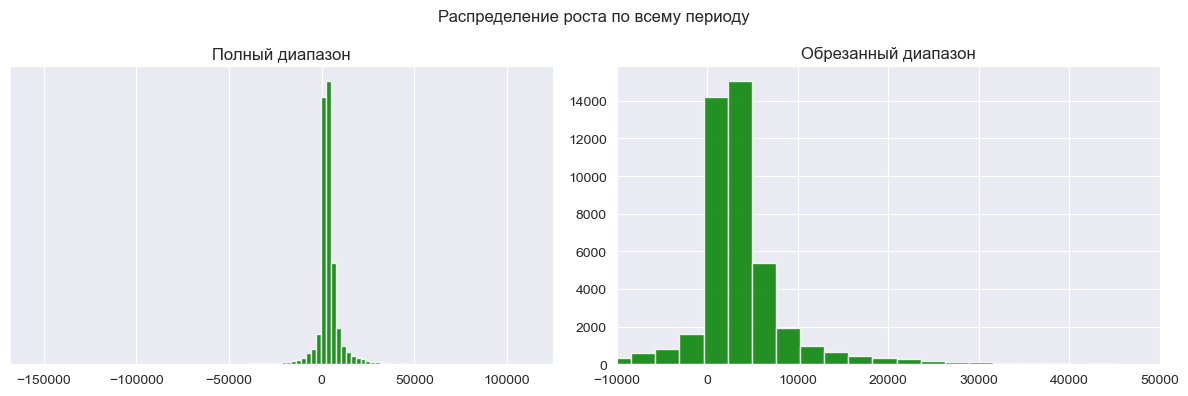

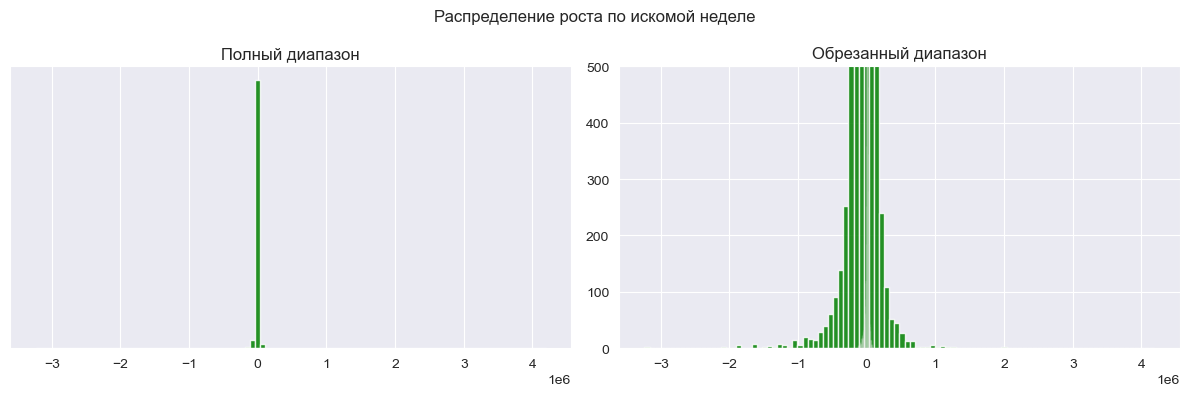

In [479]:
# распределение значений
_, axs = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle('Распределение роста по всему периоду')
axs[0].hist(pred, bins=100, color='g', alpha=.85)
axs[0].title.set_text('Полный диапазон')
axs[1].title.set_text('Обрезанный диапазон')
axs[1].hist(pred, bins=100, color='g', alpha=.85)
axs[1].set_xlim(-10000, 50000)
axs[0].set_yticks([])

plt.tight_layout()
plt.show()

_, axs = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle('Распределение роста по искомой неделе')
axs[0].hist(df_sku_week['target_growth'], bins=100, color='g', alpha=.85)
axs[0].set_yticks([])
axs[0].title.set_text('Полный диапазон')
axs[1].title.set_text('Обрезанный диапазон')
axs[1].hist(df_sku_week['target_growth'], bins=100, color='g', alpha=.85)
axs[1].hist(pred, bins=100, color='grey', alpha=.1)
axs[1].set_ylim(0, 500)
plt.tight_layout()
plt.show()

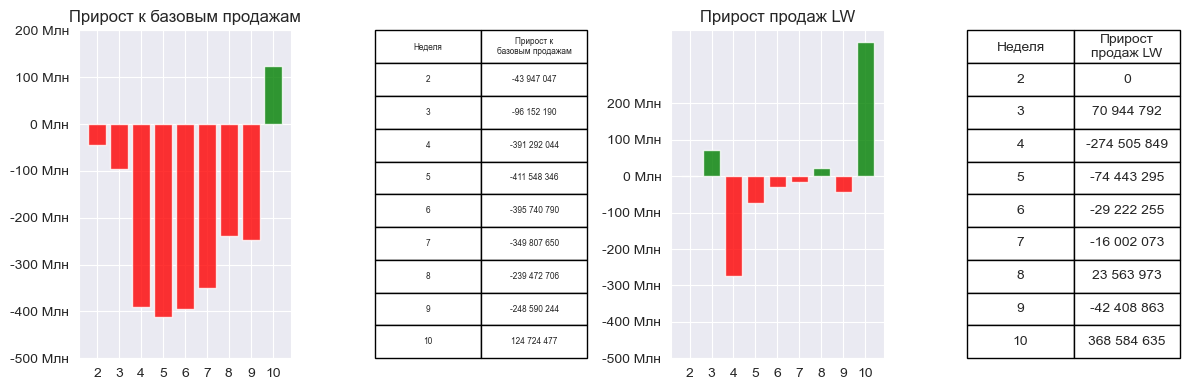

In [480]:
# прирост продаж по отношению к базовым продажам (без скидок)
week_growth = (
    df_sku_week
    .groupby('week')['target_growth']
    .sum()

)

# прирост продаж к прошлой неделе
delta = (
    (df_sku_week['target_growth'] + df_sku_week['reg_sales'])
    .groupby(df_sku_week['week'])
    .sum()
    .diff()
    #.apply(lambda x: f'{x:,.0f}'.replace(',', ' '))
    #.replace('nan', '-')
    .fillna(0)
    .to_frame()
    .round(2)
)

_, axs = plt.subplots(1, 4, figsize=(12, 4))
axs[0].bar(week_growth.index, week_growth, color=['g' if c > 0 else 'r' for c in week_growth], alpha=0.8)
axs[0].set_xticks(week_growth.index)
axs[0].set_yticks(axs[0].get_yticks(), [f'{t/10**6:.0f} Млн' for t in axs[0].get_yticks()])
axs[0].set_title('Прирост к базовым продажам')

axs[1].axis('off')
axs[1].table(
    cellText=week_growth.apply(lambda x: f'{x:,.0f}'.replace(',', ' ')).reset_index().values,
    colLabels=['Неделя', 'Прирост к\nбазовым продажам'],
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)

axs[2].bar(delta.index, delta[0], color=['g' if c > 0 else 'r' for c in delta[0]], alpha=0.8)
axs[2].set_xticks(week_growth.index)
axs[2].set_yticks(axs[0].get_yticks(), [f'{t/10**6:.0f} Млн' for t in axs[0].get_yticks()])
axs[2].set_title('Прирост продаж LW')

delta[0] = delta[0].apply(lambda x: f'{x:,.0f}'.replace(',', ' '))

axs[3].axis('off')
axs[3].table(
    cellText=delta.reset_index().values,
    colLabels=['Неделя', 'Прирост\nпродаж LW'],
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)

plt.tight_layout()
plt.show()

In [481]:
price_threshold = 999

cols = ['sku', 'product_name', 'product_brand', 'sales_tw', 'sales_lw', 'price_reg',
        'reg_sales', 'target_growth','target_growth_relative',
        'sales_vs_lw', 'disc_cost_depth_lw']

df_report['target_growth_relative'] = df_report['target_growth'] / df_report['price_reg']
mask = (df_report['target_growth'] > 0) & (df_report['price_reg'] > price_threshold)
df_top_20 = df_report.loc[mask, cols].sort_values('sales_vs_lw', ascending=False)

df_top_20.round(2)

,sku,product_name,product_brand,sales_tw,sales_lw,price_reg,reg_sales,target_growth,target_growth_relative,sales_vs_lw,disc_cost_depth_lw
255779,3857_11,сумка,cyclotech,35031.45,22083.0,1299.00,27753.75,7277.70,5.60,9.97,0.00
251837,3711_11,сумка,fila,10786.18,649.0,1049.00,6277.67,4508.51,4.30,9.66,0.38
228131,292_11,брюки,fila,69150.82,50822.0,2149.00,30611.00,38539.82,17.93,8.53,0.15
42389,1213_11,сапоги,northland,48679.31,31485.0,2099.00,41612.75,7066.56,3.37,8.19,0.00
235358,3170_11,панама,protest,11186.03,1678.0,1199.00,9592.00,1594.03,1.33,7.93,0.30
...,...,...,...,...,...,...,...,...,...,...,...
346310,733_13,шорты,demix,142235.26,218388.0,2144.03,65995.00,76240.26,35.56,-35.52,0.31
216530,257_11,кроссовки,fila,111672.46,219527.0,2999.00,97213.75,14458.71,4.82,-35.96,0.00
57473,1292_64,шорты,fila,99247.21,191501.0,2299.00,50353.00,48894.21,21.27,-40.13,0.08
129464,171_11,полуботинки,skechers,212865.12,525970.0,5599.00,177461.74,35403.38,6.32,-55.92,0.37


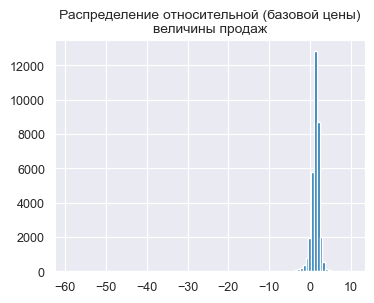

In [482]:
plt.figure(figsize=(4, 3))
plt.hist(df_top_20['sales_vs_lw'], bins=100)
plt.title('Распределение относительной (базовой цены)\nвеличины продаж', fontsize=10)
plt.tick_params(labelsize=9)
plt.show()

In [483]:
print(f'Средний прирост по SKU в единицах {df_top_20['target_growth_relative'].median():.2f}')
print(f'Средний прирост по SKU в сумме {df_top_20['target_growth'].median():.0f} руб.')
margin = .35
mask = (df_report['target_growth'] > 0)
print(f'Средняя прибыль от SKU при марже {margin}: {(df_report.loc[mask, 'target_growth'] * margin).mean():.0f} руб.')
share_positives = df_report[df_report['target_growth_relative'] > 1].shape[0] / df_report.shape[0]
print(f'Доля SKU со значимым приростом: {share_positives:.1%}')


Средний прирост по SKU в единицах 0.88
Средний прирост по SKU в сумме 3502 руб.
Средняя прибыль от SKU при марже 0.35: 1711 руб.
Доля SKU со значимым приростом: 42.7%


#### Сравнительные характеристики с результатом без участия модели*

* За основу взята рандомная симуляция промо на тестовой неделе

In [484]:
mask_test = df_sku_week['week'].eq(9)
X_test = df_sku_week[mask_test].copy()
y_test = X_test['target_growth'].copy()
promo_units_share = df_sku_week.loc[df_sku_week['week'].eq(10), 'promo_units_share_lw']

# Количество спрогнозированных SKU с позитивным приростом (кандидаты на промо) не менее 999 руб
mask_promo_cleaned = pred_cleaned > 999
n = mask_promo_cleaned.sum()


def random_promo_generator(promo_units_share, y_test, s, n):
    # вероятность попадания SKU в промо
    w = promo_units_share + 1e-6
    prob = w / w.sum()
    # генерирование рандомного числа индексов SKU для промо с помощью генератора np.random.default_rng
    rand_ind = np.random.default_rng(s).choice(y_test.index.to_numpy(), size=n, replace=False, p=prob.to_numpy())
    return y_test[rand_ind]

cumul = []
for s in range(100):
    cumul.append(random_promo_generator(promo_units_share, y_test, s, n).mean())

p05, p95 = np.quantile(cumul, [0.05, 0.95])
print(f'Разница в прибыли между предсказанным SKU и случайно выбранным для промо SKU\n'
      f'{y_test[mask_promo_cleaned].mean() - p95:.0f} руб.')
print(f'Относительная разница между моделью и случайным выбором:\n'
      f'{y_test[mask_promo_cleaned].mean()/p95 - 1:.1%}')


Разница в прибыли между предсказанным SKU и случайно выбранным для промо SKU
8843 руб.
Относительная разница между моделью и случайным выбором:
752.9%


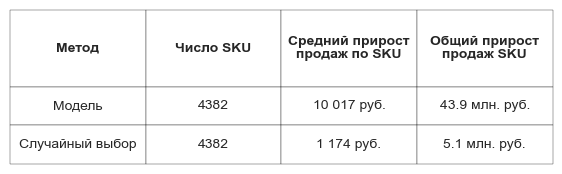

In [485]:
df_simul = pd.DataFrame(
    [
        [n, int(y_test[mask_promo_cleaned].mean()), y_test[mask_promo_cleaned].sum()],
        [n, int(p95), f'{p95 * n}']
    ],
    columns=['Число SKU', 'Средний прирост продаж по SKU', 'Общий прирост продаж SKU'],
    index=['Модель', 'Случайный выбор']
)

df_simul['Общий прирост продаж SKU'] = (df_simul['Общий прирост продаж SKU'].astype(float)
                                        .map(lambda x: f'{x/1e+6:.1f} млн. руб.'))

df_simul['Средний прирост продаж по SKU'] = (df_simul['Средний прирост продаж по SKU']
                                        .map(lambda x: f'{x:,.0f} руб.'.replace(',', ' ')))

df_simul = df_simul.reset_index()

plt.figure(figsize=(7, 2))
plt.axis('off')
table = plt.table(
    cellText=df_simul.values,
    colLabels=['Метод', 'Число SKU', 'Средний прирост\nпродаж по SKU', 'Общий прирост\nпродаж SKU'],
    loc='center',
    cellLoc='center',
    #bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_height(.5)
    else:
        cell.set_height(.25)

    cell.set_linewidth(.25)

#plt.tight_layout()
plt.savefig(f'report_images/promo_simulation.png')
plt.show()


#### Прогноз Топ 20 SKU, которые дадут лучший относительный прирост продаж по отношению к предыдущей неделе

In [486]:
cols = ['sku', 'product_name', 'product_brand', 'sales_tw', 'target_growth', 'sales_vs_lw', 'disc_cost_depth_lw']

df_top_20.head(20)[cols].round(2)

,sku,product_name,product_brand,sales_tw,target_growth,sales_vs_lw,disc_cost_depth_lw
255779,3857_11,сумка,cyclotech,35031.45,7277.70,9.97,0.00
251837,3711_11,сумка,fila,10786.18,4508.51,9.66,0.38
228131,292_11,брюки,fila,69150.82,38539.82,8.53,0.15
42389,1213_11,сапоги,northland,48679.31,7066.56,8.19,0.00
235358,3170_11,панама,protest,11186.03,1594.03,7.93,0.30
345167,729_11,кроссовки,salomon,91590.21,15777.21,7.87,0.33
100646,1539_11,кроссовки,performance,52732.44,16808.44,7.79,0.34
1367,1005_11,сабо,crocs,51158.71,4772.71,7.51,0.00
163853,1959_11,шорты,termit,20397.26,12564.26,7.49,0.43
56897,1289_11,полуботинки,outventure,16941.32,848.32,7.37,0.00


#### Прогноз Топ 20 SKU, которые дадут лучший прирост продаж по отношению к предыдущей неделе

In [487]:
# Относительный прирост продаж
cols = ['sku', 'product_name', 'product_brand', 'target_growth', 'sales_vs_lw', 'disc_cost_depth_lw']

df_top_20.head(20)[cols].round(2)

,sku,product_name,product_brand,target_growth,sales_vs_lw,disc_cost_depth_lw
255779,3857_11,сумка,cyclotech,7277.70,9.97,0.00
251837,3711_11,сумка,fila,4508.51,9.66,0.38
228131,292_11,брюки,fila,38539.82,8.53,0.15
42389,1213_11,сапоги,northland,7066.56,8.19,0.00
235358,3170_11,панама,protest,1594.03,7.93,0.30
345167,729_11,кроссовки,salomon,15777.21,7.87,0.33
100646,1539_11,кроссовки,performance,16808.44,7.79,0.34
1367,1005_11,сабо,crocs,4772.71,7.51,0.00
163853,1959_11,шорты,termit,12564.26,7.49,0.43
56897,1289_11,полуботинки,outventure,848.32,7.37,0.00


In [488]:
# топ 20 артикулов, на которых пложительно скжадется понижение действующей скидки
mask_lw_disc = df_top_20['disc_cost_depth_lw'] > .3
df_top_20.loc[mask_lw_disc, cols].round(2).head(20)

,sku,product_name,product_brand,target_growth,sales_vs_lw,disc_cost_depth_lw
251837,3711_11,сумка,fila,4508.51,9.66,0.38
235358,3170_11,панама,protest,1594.03,7.93,0.30
345167,729_11,кроссовки,salomon,15777.21,7.87,0.33
100646,1539_11,кроссовки,performance,16808.44,7.79,0.34
163853,1959_11,шорты,termit,12564.26,7.49,0.43
272798,447_11,полуботинки,skechers,27590.50,6.74,0.38
322946,637_11,сумка,reaction,4839.33,5.90,0.50
268937,4352_11,кроссовки,salomon,12736.94,5.14,0.38
232055,3062_5,худи,fila,6000.19,4.90,0.50
306026,567_11,коврик,demix,4569.58,4.64,0.47


In [489]:
# Абсолютный прирост продаж
(pd.concat(
    [
        df_top_20[cols],
        df_top_20['sales_tw'].sub(df_top_20['sales_lw'])
    ],
    axis=1)
 .round(2)
 .rename(columns={0: 'sales_growth'})
 .sort_values('sales_growth', ascending=False)
 .head(20)
)

,sku,product_name,product_brand,target_growth,sales_vs_lw,disc_cost_depth_lw,sales_growth
366515,8225_551,доска,jp-australia,9041.63,1.64,0.0,107681.63
145943,182_5,стол,torneo,15339.30,2.32,0.0,103212.30
36674,11861_690,байдарка,noname,8028.93,1.09,0.0,101027.93
402830,9867_153,велосипед,scott,8776.29,1.10,0.0,100775.29
387980,9182_28,ботинки,salomon,3651.69,1.04,0.0,98650.69
10943,10549_551,доска,jp-australia,10895.69,1.50,0.0,98575.69
364382,8130_13,пуховик,fjallraven,9391.04,1.11,0.0,96390.04
178064,20631_13,пуховик,descente,3584.64,1.04,0.0,94583.64
377954,8730_23,лыжи,volkl,23952.22,1.35,0.0,93251.22
342089,7180_11,велосипед,merida,3250.18,1.04,0.0,93249.18


#### Анализ рисков на основании признаков непостоянства таргета в рамках SKU (волатильности) за последние 4 недели и аномальных значений

In [490]:
group = df_sku_week.groupby('sku')

In [491]:
# подсчет z-оценки для каждого SKU для определения аномали по правилу трех сигм
s_z = (df_sku_week['target_growth']
        .sub(group['target_growth'].transform('mean'))
        .divide(group['target_growth'].transform('std')))

print(f'Наличие признаков аномального прироста у SKU за всю историю датасета (8 недель): '
      f'{(s_z > 3).any()}')
 # правило 3х сигм

Наличие признаков аномального прироста у SKU за всю историю датасета (8 недель): False


In [492]:
# добавление признака волатильности для каждого SKU (std / mean)
# низкая волатильность std / mean < 50%
# средняя волатильность 50% < std / mean < 100%
# низкая волатильность std / mean > 100% - признак большой переменчивости sku создает риски для точности предсказания
coef_variation = (
    df_sku_week.groupby(df_sku_week['sku']).shift().groupby(df_sku_week['sku'])['target_growth'].rolling(4, 2).std().reset_index(level=0, drop=True)[mask_unknown]
    /
    df_sku_week.groupby(df_sku_week['sku']).shift().groupby(df_sku_week['sku'])['target_growth'].rolling(4, 2).mean().reset_index(level=0, drop=True)[mask_unknown]
).abs().fillna(0)

df_report['volatility'] = np.select(
    [coef_variation < .5, coef_variation > 1],
    ['low', 'high'],
    default='medium'
)

In [493]:
df_report.loc[df_report['target_growth'] > 0, 'volatility'].value_counts(normalize=True)

volatility
high      0.376888
low       0.321754
medium    0.301359
Name: proportion, dtype: float64

In [494]:
# Тoп 20 SKU по относительному приросту продаж с базовой ценой выше 999 руб и волатильностью не больше средней
cols = ['sku', 'product_name', 'product_brand', 'target_growth', 'sales_vs_lw', 'disc_cost_depth_lw', 'volatility']

mask = ((df_report['target_growth'] > 0)
        & (df_report['price_reg'] > price_threshold)
        & (df_report['volatility'] != 'high'))

(
    df_report.loc[mask, cols]
    .sort_values('sales_vs_lw', ascending=False)
    .head(20)
)

,sku,product_name,product_brand,target_growth,sales_vs_lw,disc_cost_depth_lw,volatility
262385,410_11,слипоны,skechers,3841.254798,6.580862,0.000000,medium
269099,435_5,очки,kappa,18111.611359,6.479204,0.125591,medium
57383,1292_11,шорты,fila,22776.759507,6.084964,0.239496,medium
322946,637_11,сумка,reaction,4839.333796,5.903852,0.500455,low
240353,3327_11,кроссовки,mandala,21030.277821,5.559690,0.000000,medium
389006,9232_11,шлепанцы,joss,2197.177462,5.392482,0.000000,low
52136,12635_2,доска,mad,5122.932671,5.304985,0.000000,medium
52145,12635_51,доска,mad,5117.700497,5.300589,0.000000,low
764,1002_11,брюки,demix,18790.196207,5.279501,0.170473,medium
58184,1295_11,бейсболка,new era,9119.775667,5.122229,0.186196,medium


#### Анализ адекватности работы модели и пример настройки сетки параметров путем моделирования различных стратегий ценообразования

In [495]:
# mask = df_sku_week['week'].eq(10)
# df_sku_week.loc[mask, 'disc_depth_max'] = .3
# df_sku_week.loc[mask, 'disc_depth_min'] = .2
# df_sku_week.loc[mask, ['promo_flag', 'base_sale_flag']] = 1

In [496]:
from IPython.display import clear_output

mask = df_sku_week_cleaned['week'].eq(10)
lift_dict = {i: [] for i in range(4)}

max_list = np.sort(np.append(np.arange(.1, .4, .05), np.array([.5, .6, .8]))).round(3)

mode = 'recreate'

if mode == 'load':

    for max_value in max_list:
        min_list_prior = np.array([.1, float(max_value/2), float(max_value - .1)])
        min_list = np.append(
            np.where(
                (min_list_prior < .1) | (min_list_prior == max_value),
                np.nan,
                min_list_prior
            ),
            max_value
        )
        clear_output()
        print(max_value, min_list)

        for i, min_value in enumerate(min_list):
            if min_list[i] == min_list[i-1]:
                lift_dict[i].append(int(pr.sum()))
            elif np.isnan(min_value):
                lift_dict[i].append(min_value)
            else:
                df_sku_week_cleaned.loc[mask, 'disc_depth_max'] = max_value
                df_sku_week_cleaned.loc[mask, 'disc_depth_min'] = min_value
                #df_sku_week_cleaned.loc[mask, 'is_disc_depth_mix'] = (i!=3)*1
                df_sku_week_cleaned.loc[mask, ['promo_flag', 'base_sale_flag']] = 1

                pr = modeling(df_sku_week_cleaned, mode='predict')
                lift_dict[i].append(int(pr.sum()))

    with open('data/share_dict.json', 'w') as f:
        json.dump(lift_dict, f)

else:
    with open('data/share_dict.json', 'r') as f:
        lift_dict = json.load(f)

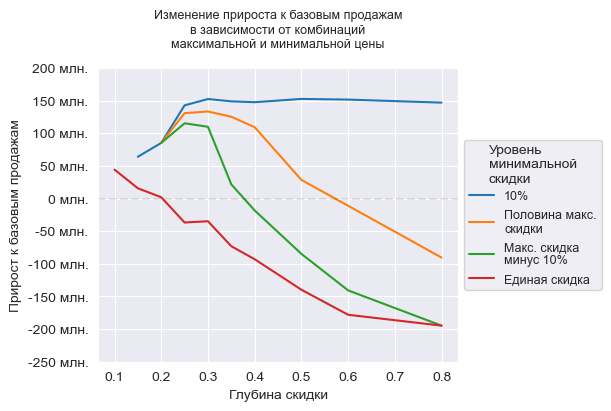

In [497]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

pd.DataFrame(lift_dict).set_axis(max_list, axis=0).plot(ax=ax);

plt.axhline(0, color='k', linestyle='--', alpha=0.1)
tick_list = np.arange(0.1, .9, .1)
plt.xticks(tick_list)
plt.yticks(plt.yticks()[0], [f'{t:.0f} млн.' for t in plt.yticks()[0] / 1e+6])

leg_labels = ['10%', 'Половина макс.\nскидки', 'Макс. скидка\nминус 10%', 'Единая скидка']
plt.legend(leg_labels, bbox_to_anchor=(1, .5), loc='center left', title='Уровень\nминимальной\nскидки', fontsize=9)
plt.title('Изменение прироста к базовым продажам\nв зависимости от комбинаций\nмаксимальной и минимальной цены\n', fontsize=9)
plt.xlabel('Глубина скидки')
plt.ylabel('Прирост к базовым продажам')

plt.savefig('report_images/lift_vs_discount.png')
plt.show()

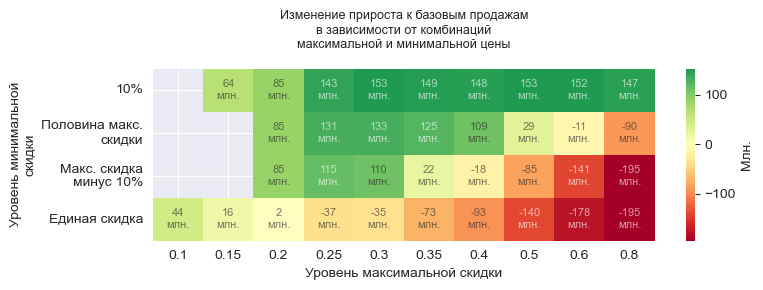

In [498]:

df_promo_strategies = pd.DataFrame(lift_dict).set_axis(max_list, axis=0)

plt.figure(figsize=(8, 3))

ax = sns.heatmap(df_promo_strategies.T / 1e+6, cmap='RdYlGn', center=0, annot=True, fmt='.0f', cbar_kws={'label': 'Млн.'}, annot_kws={'size': 8, 'alpha': 0.6});

ax.set_xlabel('Уровень максимальной скидки')
ax.set_ylabel('Уровень минимальной\nскидки')
ax.set_yticklabels(leg_labels, rotation=0)
ax.set_title('Изменение прироста к базовым продажам\nв зависимости от комбинаций\nмаксимальной и минимальной цены\n', fontsize=9)

for text in ax.texts:
    text.set_text(text.get_text() + '\nмлн.')

plt.tight_layout()
plt.savefig('report_images/promo_strategies.png')
plt.show()

Общие рекомендации - динамическое ценообразование превосходит по эффективности простую скидку на все. Применение высокой минимальной скидки снижает эффективность промо и ведет к убыткам. Таким образом, следует воздержаться от простого понижения цен на одинаковую величину, лучшей общей комбинацией будет применение максимальной скидки в 30-50% на часть ассортимента, при этом на другую часть ассортимента лучше назначить маленькую скидку или оставить цену на него без изменения.

In [499]:
# сохранение прогнозов с лучшими результатами в датасет для проработки маркетингом
df_sku_week_cleaned.loc[mask, 'disc_depth_max'] = .3
df_sku_week_cleaned.loc[mask, 'disc_depth_min'] = .1
df_sku_week_cleaned.loc[mask, ['promo_flag', 'base_sale_flag']] = 1

pred_best = modeling(df_sku_week_cleaned, mode='predict')

df_ultimate = df_sku_week_cleaned.copy()

cols = [
    'sku', 'week', 'product_id', 'product_brand',  'product_name', 'colour_id', 'basic_colour',
    'prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys', 'prod_girls',
    'price_reg', 'price_reg_level', 'reg_sales', 'promo_flag', 'base_sale_flag',
    'sales_tw', 'quantity_prev_week', 'sales_prev_week', 'target_growth',
    'n_clients_prev_week', 'avg_gender_prev_week',
    'disc_depth_max', 'disc_depth_min', 'disc_cost_depth_lw',
]

df_ultimate.loc[df_ultimate['target_growth'].isna(), 'target_growth'] = pred_best
df_ultimate['sales_tw'] = df_ultimate['target_growth'] + df_ultimate['reg_sales']

df_ultimate[cols].to_csv('data/df_ultimate.csv', index=False)

In [500]:
df_ultimate[cols]

,sku,week,product_id,product_brand,product_name,colour_id,basic_colour,prod_adults,prod_kids,prod_men,...,base_sale_flag,sales_tw,quantity_prev_week,sales_prev_week,target_growth,n_clients_prev_week,avg_gender_prev_week,disc_depth_max,disc_depth_min,disc_cost_depth_lw
1,10000_11,3,10000,redmi,фитнес,11,unknown,0,0,0,...,0.0,29880.000000,0.0,0.0,9515.357143,0.0,0.000000,0.0,0.0,0.0
2,10000_11,4,10000,redmi,фитнес,11,unknown,0,0,0,...,0.0,12450.000000,12.0,29880.0,-17430.000000,11.0,0.583333,0.0,0.0,0.0
3,10000_11,5,10000,redmi,фитнес,11,unknown,0,0,0,...,0.0,24900.000000,5.0,12450.0,3735.000000,5.0,1.000000,0.0,0.0,0.0
4,10000_11,6,10000,redmi,фитнес,11,unknown,0,0,0,...,0.0,24900.000000,10.0,24900.0,2490.000000,9.0,0.600000,0.0,0.0,0.0
5,10000_11,7,10000,redmi,фитнес,11,unknown,0,0,0,...,0.0,9960.000000,10.0,24900.0,-13072.500000,9.0,0.700000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405526,9_4,6,9,fila,шлем,4,white,0,0,0,...,0.0,0.000000,1.0,4999.0,-9998.000000,1.0,0.000000,0.0,0.0,0.0
405527,9_4,7,9,fila,шлем,4,white,0,0,0,...,0.0,4999.000000,0.0,0.0,-6665.333333,0.0,0.000000,0.0,0.0,0.0
405528,9_4,8,9,fila,шлем,4,white,0,0,0,...,0.0,4999.000000,1.0,4999.0,-3332.666667,1.0,1.000000,0.0,0.0,0.0
405529,9_4,9,9,fila,шлем,4,white,0,0,0,...,0.0,0.000000,1.0,4999.0,-4999.000000,1.0,1.000000,0.0,0.0,0.0
